<a href="https://colab.research.google.com/github/Mathildeholst/Speciale/blob/main/Eksperimenter_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#FoR-dataset

Load the dataset

In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os, shutil

drive_path = "/content/drive/MyDrive/Speciale/for-rerecorded 2"
local_path = "/content/for-rerec"

if not os.path.exists(local_path):
    shutil.copytree(drive_path, local_path)

base_path  = local_path
train_path = os.path.join(base_path, "training")
val_path   = os.path.join(base_path, "validation")
test_path  = os.path.join(base_path, "testing")

Mounted at /content/drive


Check the split og the data

In [2]:
import os

for split in ["training", "validation", "testing"]:
    for label in ["real", "fake"]:
        path = f"/content/for-rerec/{split}/{label}"
        if os.path.exists(path):
            count = len(os.listdir(path))
            print(f"{split}/{label}: {count} files")

training/real: 5104 files
training/fake: 5104 files
validation/real: 1101 files
validation/fake: 1143 files
testing/real: 408 files
testing/fake: 408 files


# Comparison of the different spectrogram types: STFT, MEL, MFCC and CQT

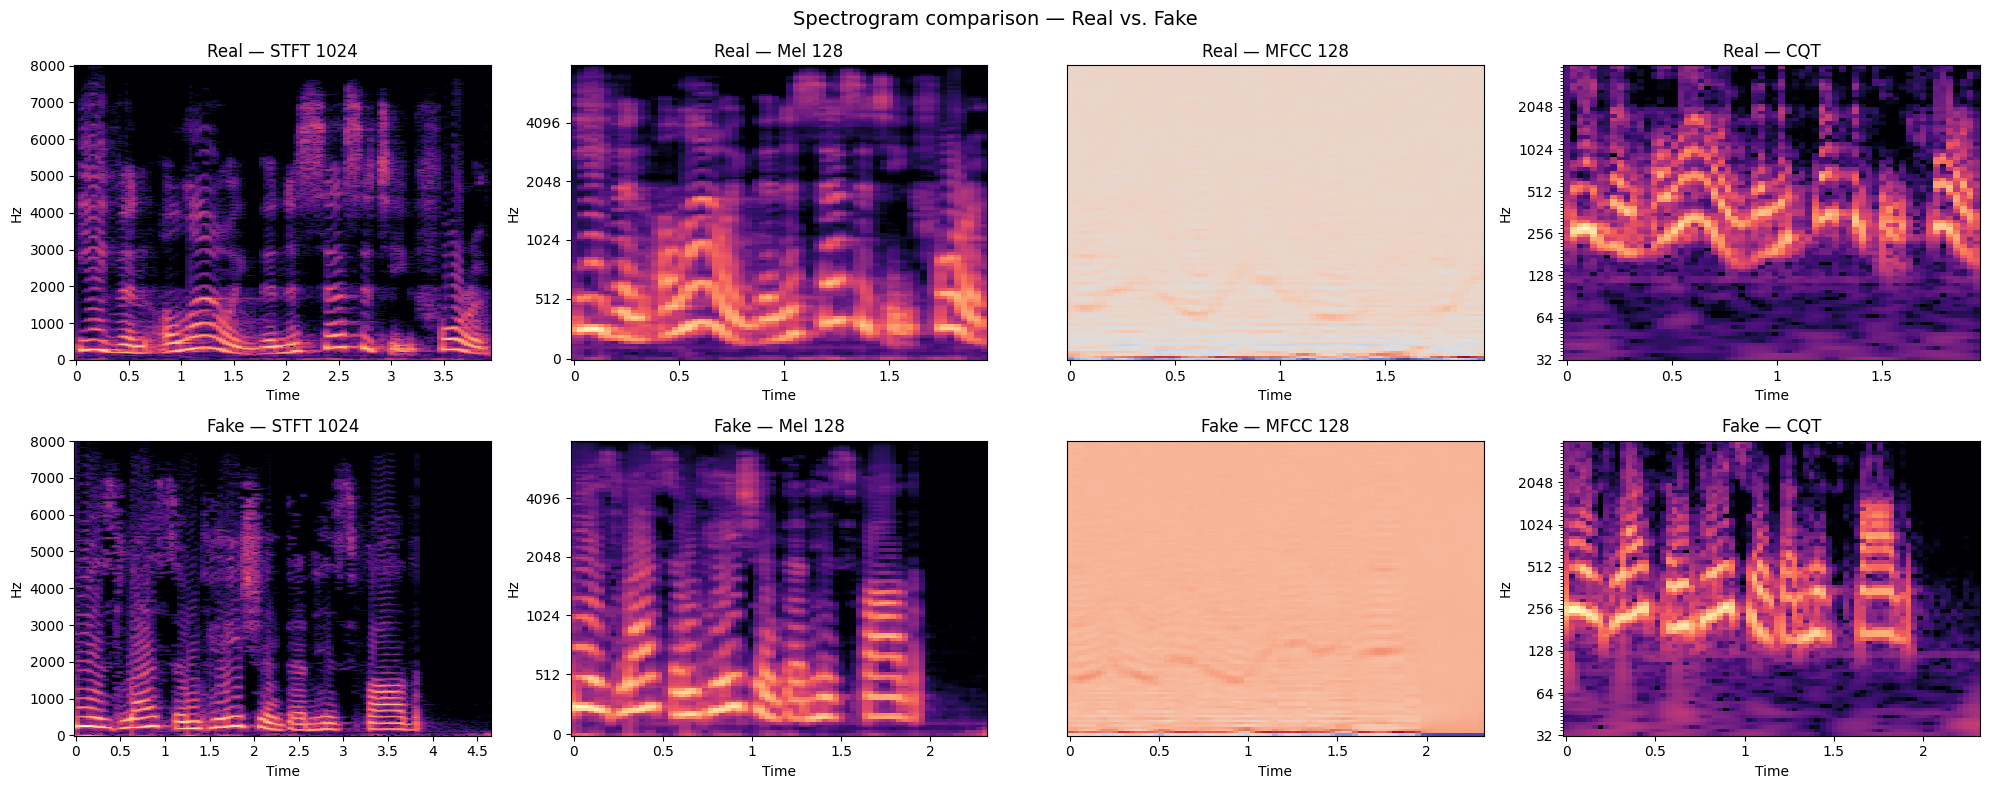

In [3]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os

real_path = "/content/for-rerec/training/real"
fake_path = "/content/for-rerec/training/fake"

real_file = os.path.join(real_path, os.listdir(real_path)[0])
fake_file = os.path.join(fake_path, os.listdir(fake_path)[0])

def load_spectrograms(file_path):
    y, sr = librosa.load(file_path, sr=None)

    stft = librosa.amplitude_to_db(np.abs(librosa.stft(y, n_fft=1024)), ref=np.max)
    mel  = librosa.power_to_db(librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128), ref=np.max)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=128)
    cqt  = librosa.amplitude_to_db(np.abs(librosa.cqt(y, sr=sr)), ref=np.max)

    return sr, stft, mel, mfcc, cqt

sr_r, stft_r, mel_r, mfcc_r, cqt_r = load_spectrograms(real_file)
sr_f, stft_f, mel_f, mfcc_f, cqt_f = load_spectrograms(fake_file)

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle("Spectrogram comparison — Real vs. Fake", fontsize=14)

librosa.display.specshow(stft_r, sr=sr_r, ax=axes[0,0], x_axis='time', y_axis='hz')
axes[0,0].set_title("Real — STFT 1024")

librosa.display.specshow(mel_r, sr=sr_r, ax=axes[0,1], x_axis='time', y_axis='mel')
axes[0,1].set_title("Real — Mel 128")

librosa.display.specshow(mfcc_r, sr=sr_r, ax=axes[0,2], x_axis='time')
axes[0,2].set_title("Real — MFCC 128")

librosa.display.specshow(cqt_r, sr=sr_r, ax=axes[0,3], x_axis='time', y_axis='cqt_hz')
axes[0,3].set_title("Real — CQT")

librosa.display.specshow(stft_f, sr=sr_f, ax=axes[1,0], x_axis='time', y_axis='hz')
axes[1,0].set_title("Fake — STFT 1024")

librosa.display.specshow(mel_f, sr=sr_f, ax=axes[1,1], x_axis='time', y_axis='mel')
axes[1,1].set_title("Fake — Mel 128")

librosa.display.specshow(mfcc_f, sr=sr_f, ax=axes[1,2], x_axis='time')
axes[1,2].set_title("Fake — MFCC 128")

librosa.display.specshow(cqt_f, sr=sr_f, ax=axes[1,3], x_axis='time', y_axis='cqt_hz')
axes[1,3].set_title("Fake — CQT")

plt.tight_layout()
plt.savefig("spectrogram_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

#Model Choices

Custom CNNs (trained from scratch)
* 1. Simple CNN
A basic convolutional neural network with 3 convolutional layers (16→32→64 filters) followed by max pooling. Serves as a baseline to compare against more complex models.
* 2. Improved CNN
An enhanced architecture using residual blocks with separable convolutions (32→64→128→256 filters). Includes batch normalization for stable training and uses global average pooling instead of flattening to reduce parameters.
* 3. Improved CNN + SpecAugment
Same as Improved CNN but with added data augmentation during training. SpecAugment randomly masks parts of the spectrogram in frequency and time dimensions, helping the model generalize better to unseen data.
* 4. Mini-Xception
A lightweight version of the Xception architecture using depthwise separable convolutions with residual connections. Designed to be computationally efficient while maintaining high performance through its sophisticated skip connections.

Pretrained Models (transfer learning from ImageNet)
* 5. MobileNetV2
A mobile-optimized architecture using depthwise separable convolutions to reduce computational cost. Pre-trained on ImageNet and fine-tuned on spectrograms. The last 5 layers are unfrozen for task-specific learning.
* 6. VGG16
A classic deep architecture with 16 layers using small 3×3 convolutional filters stacked in blocks. Known for its simplicity and effectiveness. The last 5 layers are unfrozen for fine-tuning.
* 7. VGG19 Standard
Similar to VGG16 but deeper with 19 layers. Uses the same block-based design with 3×3 filters. The last 10 layers are unfrozen, allowing more adaptation to the spectrogram data.
* 8. VGG19 Optimized
A specialized variant of VGG19 with custom preprocessing: spectrograms are vertically flipped before feeding to the network. Only the last 5 layers are unfrozen, and uses a simpler classifier head with single dropout layer.
* 9. ResNet50
A 50-layer residual network that uses skip connections to address the vanishing gradient problem in very deep networks. The last 10 layers are unfrozen for domain adaptation to audio spectrograms.

#CQT

###Imports and parametre

In [4]:
import os, math, shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import librosa
import librosa.display
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, classification_report,
    f1_score, roc_auc_score, roc_curve,
    recall_score, precision_score
)
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint

SR              = 16000
DURATION        = 2.0
TARGET_LEN      = int(SR * DURATION)
HOP_LENGTH      = 256
FMIN            = 32.7
N_BINS          = 168
BINS_PER_OCTAVE = 24
BATCH_SIZE      = 16
EPOCHS          = 50
INITIAL_LR      = 5e-5
PATIENCE        = 10

base_path  = "/content/for-rerec"
train_path = os.path.join(base_path, "training")
val_path   = os.path.join(base_path, "validation")
test_path  = os.path.join(base_path, "testing")

CQT funktion og load data

In [5]:
def create_cqt(filepath):
    audio, _ = librosa.load(filepath, sr=SR, mono=True)
    if len(audio) < TARGET_LEN:
        audio = np.pad(audio, (0, TARGET_LEN - len(audio)))
    else:
        audio = audio[:TARGET_LEN]
    C = librosa.cqt(
        audio, sr=SR,
        hop_length=HOP_LENGTH,
        fmin=FMIN,
        n_bins=N_BINS,
        bins_per_octave=BINS_PER_OCTAVE
    )
    C_db = librosa.amplitude_to_db(np.abs(C), ref=np.max)
    return C_db.astype(np.float32)

def get_paths(split_path):
    real = sorted([
        os.path.join(split_path, "real", f)
        for f in os.listdir(os.path.join(split_path, "real"))
        if f.endswith(".wav")
    ])
    fake = sorted([
        os.path.join(split_path, "fake", f)
        for f in os.listdir(os.path.join(split_path, "fake"))
        if f.endswith(".wav")
    ])
    return real, fake

def load_split(split_path):
    real, fake = get_paths(split_path)
    X, y = [], []
    for fp in real:
        X.append(create_cqt(fp))
        y.append(1)
    for fp in fake:
        X.append(create_cqt(fp))
        y.append(0)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

print("Loading data...")
X_train, y_train = load_split(train_path)
X_val, y_val = load_split(val_path)
X_test, y_test = load_split(test_path)

print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)
print(f"Data range: {X_train.min():.2f} to {X_train.max():.2f}")

Loading data...


/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=500
  warnings.warn(


Train: (10208, 168, 126)
Val:   (2244, 168, 126)
Test:  (816, 168, 126)
Data range: -80.00 to 0.00


RGB Conversions

Pretrained modeller (MobileNet, VGG, ResNet) blev trænet på normale billeder med pixel-værdier [0, 255].
Z-score normalisering ændrer dine spektrogrammer til range [-3, +3].
Når du laver RGB conversion på Z-score data → alle værdier bliver til -1.008 (næsten ens) → modellen ser et helt sort/uniformt billede → kan ikke lære noget → 50% accuracy.
Løsning:

Custom CNNs (Simple, Improved) → brug Z-score data ✅
Pretrained modeller → brug ORIGINAL data (dB range) ✅

Derfor: Lav RGB conversion FØR Z-score normalisering! 🎯

In [6]:
def to_rgb_resized(X, size):
    """Convert grayscale spectrograms to RGB and resize."""
    results = []
    for spec in X:
        spec_rgb = np.stack([spec, spec, spec], axis=-1)
        spec_resized = tf.image.resize(spec_rgb, (size, size)).numpy()
        results.append(spec_resized)
    return np.array(results, dtype=np.float32)

print("Converting to RGB (from ORIGINAL data)...")
X_train_rgb96 = to_rgb_resized(X_train, 96)
X_val_rgb96   = to_rgb_resized(X_val, 96)
X_test_rgb96  = to_rgb_resized(X_test, 96)

X_train_vgg = to_rgb_resized(X_train, 224)
X_val_vgg   = to_rgb_resized(X_val, 224)
X_test_vgg  = to_rgb_resized(X_test, 224)

print("RGB 96 (MobileNet):", X_train_rgb96.shape)
print("VGG 224 (VGG16/VGG19/ResNet50):", X_train_vgg.shape)
print(f"RGB96 data range: {X_train_rgb96.min():.2f} to {X_train_rgb96.max():.2f}")

Converting to RGB (from ORIGINAL data)...
RGB 96 (MobileNet): (10208, 96, 96, 3)
VGG 224 (VGG16/VGG19/ResNet50): (10208, 224, 224, 3)
RGB96 data range: -80.00 to -0.02


In [7]:
print("TJEK SHAPES:")
print(f"X_train (original): {X_train.shape}")
print(f"X_train_rgb96: {X_train_rgb96.shape}")
print(f"y_train: {y_train.shape}")

TJEK SHAPES:
X_train (original): (10208, 168, 126)
X_train_rgb96: (10208, 96, 96, 3)
y_train: (10208,)


Z-score normalisering

In [8]:
print("Z-score normalizing for custom CNNs...")

mean = X_train.mean(axis=(0, 1, 2), keepdims=True)
std  = X_train.std(axis=(0, 1, 2), keepdims=True) + 1e-8

X_train_norm = (X_train - mean) / std
X_val_norm   = (X_val   - mean) / std
X_test_norm  = (X_test  - mean) / std

X_train_norm = X_train_norm[..., np.newaxis]
X_val_norm   = X_val_norm[..., np.newaxis]
X_test_norm  = X_test_norm[..., np.newaxis]

print("Normalized train shape:", X_train_norm.shape)
print("Normalized val shape:  ", X_val_norm.shape)
print("Normalized test shape: ", X_test_norm.shape)

print(f"\nZ-scored data - Mean: {X_train_norm.mean():.6f}, Std: {X_train_norm.std():.6f}")
print(f"Z-scored range: {X_train_norm.min():.2f} to {X_train_norm.max():.2f}")

Z-score normalizing for custom CNNs...
Normalized train shape: (10208, 168, 126, 1)
Normalized val shape:   (2244, 168, 126, 1)
Normalized test shape:  (816, 168, 126, 1)

Z-scored data - Mean: -0.000009, Std: 1.000001
Z-scored range: -1.63 to 3.07


Help functions

In [9]:
class CosineAnnealingScheduler(Callback):
    def __init__(self, T_max, eta_max, eta_min=1e-6, verbose=0):
        super().__init__()
        self.T_max   = T_max
        self.eta_max = eta_max
        self.eta_min = eta_min
        self.verbose = verbose

    def on_epoch_begin(self, epoch, logs=None):
        lr = self.eta_min + (self.eta_max - self.eta_min) * (
            1 + math.cos(math.pi * epoch / self.T_max)
        ) / 2
        self.model.optimizer.learning_rate.assign(lr)
        if self.verbose:
            print(f"  LR: {lr:.2e}")

def get_callbacks(model_name):
    return [
        EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True, verbose=1),
        CosineAnnealingScheduler(T_max=EPOCHS, eta_max=INITIAL_LR, eta_min=1e-6),
        ModelCheckpoint(f"/content/{model_name}.keras", monitor="val_loss", save_best_only=True, verbose=1)
    ]

def equal_error_rate(y_true, y_scores):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    fnr = 1 - tpr
    idx = np.argmin(np.abs(fpr - fnr))
    return float(fpr[idx])

def bootstrap_ci(y_true, y_scores, n=1000, alpha=0.05):
    accs = []
    n_samples = len(y_true)
    for _ in range(n):
        idx = np.random.randint(0, n_samples, size=n_samples)
        y_b = y_true[idx]
        y_s = y_scores[idx]
        y_p = (y_s >= 0.5).astype(int)
        accs.append(accuracy_score(y_b, y_p))
    lower = np.percentile(accs, 100 * alpha / 2)
    upper = np.percentile(accs, 100 * (1 - alpha / 2))
    return np.mean(accs), lower, upper

def evaluate_model(model, X, y, model_name):
    y_prob  = model.predict(X, verbose=0).ravel()
    y_pred  = (y_prob >= 0.5).astype(int)
    acc     = accuracy_score(y, y_pred)
    recall  = recall_score(y, y_pred)
    prec    = precision_score(y, y_pred, zero_division=0)
    f1      = f1_score(y, y_pred)
    auc     = roc_auc_score(y, y_prob)
    eer     = equal_error_rate(y, y_prob)
    mean_acc, ci_low, ci_high = bootstrap_ci(y, y_prob)

    print(f"\n=== {model_name} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"AUC-ROC:   {auc:.4f}")
    print(f"EER:       {eer:.4f}")
    print(f"Bootstrap: {mean_acc:.4f} [{ci_low:.4f}, {ci_high:.4f}]")

    return {
        "model": model_name, "accuracy": acc, "recall": recall,
        "precision": prec, "f1": f1, "auc": auc, "eer": eer,
        "ci_low": ci_low, "ci_high": ci_high
    }

def plot_history(history, model_name):
    best_val_acc = max(history.history["val_accuracy"])
    print(f"Best val accuracy ({model_name}): {best_val_acc:.4f}")
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train")
    plt.plot(history.history["val_accuracy"], label="Validation")
    plt.title(f"{model_name} – Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train")
    plt.plot(history.history["val_loss"], label="Validation")
    plt.title(f"{model_name} – Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
    plt.tight_layout(); plt.show()

SpecAugment og residual block

In [10]:
class SpecAugment(layers.Layer):
    def __init__(self, freq_mask=10, time_mask=15, **kwargs):
        super().__init__(**kwargs)
        self.freq_mask = freq_mask
        self.time_mask = time_mask

    def call(self, x, training=None):
        if not training:
            return x
        freq = tf.shape(x)[1]
        time = tf.shape(x)[2]

        f  = tf.random.uniform([], 0, self.freq_mask, dtype=tf.int32)
        f0 = tf.random.uniform([], 0, freq - f, dtype=tf.int32)
        freq_mask = 1.0 - tf.cast(
            tf.sequence_mask(f, freq) & ~tf.sequence_mask(f0, freq),
            dtype=x.dtype
        )
        freq_mask = tf.reshape(freq_mask, [1, freq, 1, 1])
        x = x * freq_mask

        t  = tf.random.uniform([], 0, self.time_mask, dtype=tf.int32)
        t0 = tf.random.uniform([], 0, time - t, dtype=tf.int32)
        time_mask = 1.0 - tf.cast(
            tf.sequence_mask(t, time) & ~tf.sequence_mask(t0, time),
            dtype=x.dtype
        )
        time_mask = tf.reshape(time_mask, [1, 1, time, 1])
        x = x * time_mask
        return x

def residual_block(x, filters):
    shortcut = x
    x = layers.SeparableConv2D(filters, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.SeparableConv2D(filters, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1,1), padding="same", use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)
    return x

###Model 1: Simple CNN

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 168, 126, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 84, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 84, 63, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 42, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 42, 31, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 21, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20160)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │     1,290,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313,665 (5.01 MB)

 Trainable params: 1,313,665 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
636/638 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6804 - loss: 0.5954
Epoch 1: val_loss improved from None to 0.34305, saving model to /content/simple_cnn_cqt.keras

Epoch 1: finished saving model to /content/simple_cnn_cqt.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.7672 - loss: 0.5002 - val_accuracy: 0.8681 - val_loss: 0.3430
Epoch 2/50
633/638 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8679 - loss: 0.3197
Epoch 2: val_loss improved from 0.34305 to 0.25794, saving model to /content/simple_cnn_cqt.keras

Epoch 2: finished saving model to /content/simple_cnn_cqt.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8705 - loss: 0.3083 - val_accuracy: 0.8855 - val_loss: 0.2579
Epoch 3/50
635/638 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8858 - loss: 0.2594
Epoch 3: val_loss improved from 0.25794 to 0.22430, saving model to /content/simple_cnn_cqt.keras

Epoch 3: finished saving model to /content/simple_cnn_cqt.keras
638/638 ━━━━━━━━━━━━

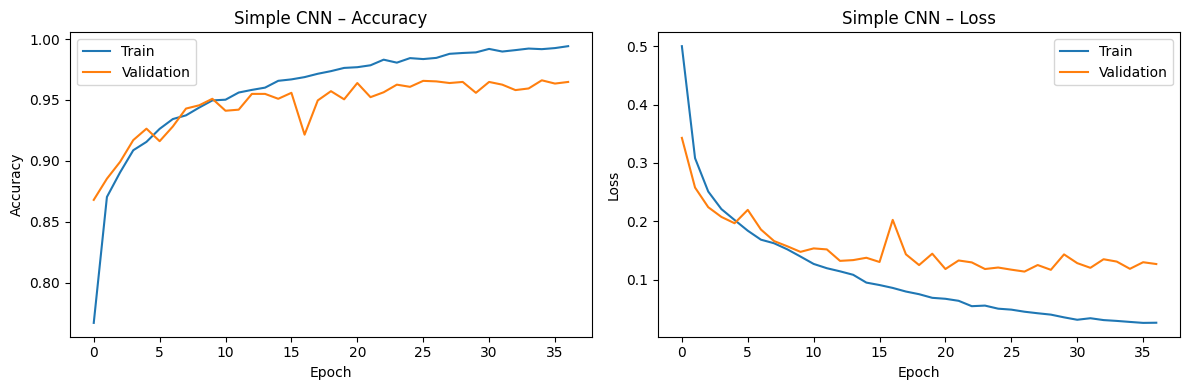


=== Simple CNN ===
Accuracy:  0.8738
Recall:    0.9289
Precision: 0.8366
F1-score:  0.8804
AUC-ROC:   0.9303
EER:       0.1054
Bootstrap: 0.8737 [0.8517, 0.8946]


In [13]:
input_shape = X_train_norm.shape[1:]
simple_cnn = models.Sequential([
    layers.Input(shape=input_shape),
    layers.Conv2D(16, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

simple_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
simple_cnn.summary()

history_simple = simple_cnn.fit(
    X_train_norm, y_train,
    validation_data=(X_val_norm, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks("simple_cnn_cqt")
)
plot_history(history_simple, "Simple CNN")
results_simple = evaluate_model(simple_cnn, X_test_norm, y_test, "Simple CNN")

###Model 2: Improved CNN

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 168, 126,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 168, 126,  │        288 │ input_layer_5[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 168, 126,  │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 168, 126,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 84, 63,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 84, 63,    │      2,336 │ max_pooling2d_3[… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 84, 63,    │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 84, 63,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 84, 63,    │      4,672 │ activation_1[0][… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 84, 63,    │      2,048 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 84, 63,    │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 84, 63,    │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 84, 63,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 84, 63,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 42, 31,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 42, 31,    │      8,768 │ max_pooling2d_4[… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 42, 31,    │        512 │ separable_conv2d

 Total params: 184,129 (719.25 KB)

 Trainable params: 181,377 (708.50 KB)

 Non-trainable params: 2,752 (10.75 KB)

Epoch 1/50
636/638 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6791 - loss: 0.5758
Epoch 1: val_loss improved from None to 1.10662, saving model to /content/improved_cnn_cqt.keras

Epoch 1: finished saving model to /content/improved_cnn_cqt.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 45s 39ms/step - accuracy: 0.7638 - loss: 0.4790 - val_accuracy: 0.4978 - val_loss: 1.1066
Epoch 2/50
637/638 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8503 - loss: 0.3450
Epoch 2: val_loss improved from 1.10662 to 0.91973, saving model to /content/improved_cnn_cqt.keras

Epoch 2: finished saving model to /content/improved_cnn_cqt.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.8656 - loss: 0.3215 - val_accuracy: 0.6012 - val_loss: 0.9197
Epoch 3/50
637/638 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8943 - loss: 0.2512
Epoch 3: val_loss improved from 0.91973 to 0.32578, saving model to /content/improved_cnn_cqt.keras

Epoch 3: finished saving model to /content/improved_cnn_cqt.keras
638

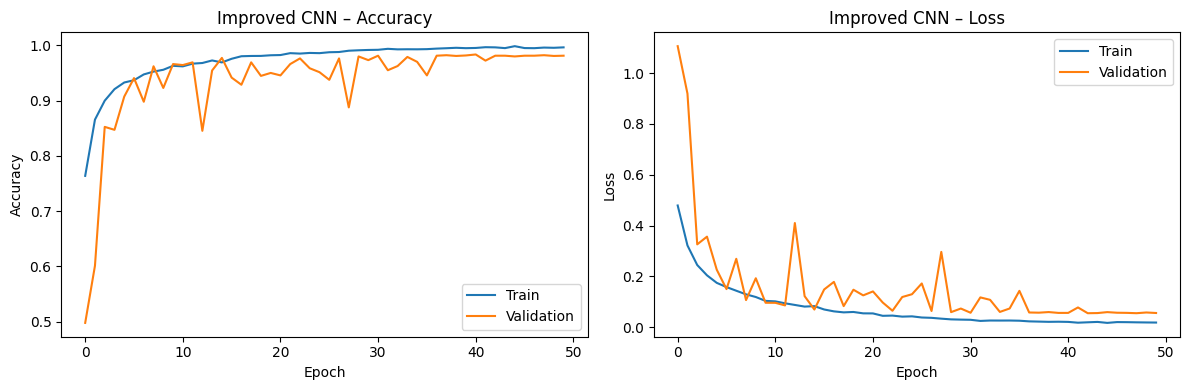


=== Improved CNN ===
Accuracy:  0.7782
Recall:    0.8873
Precision: 0.7284
F1-score:  0.8000
AUC-ROC:   0.8626
EER:       0.2059
Bootstrap: 0.7776 [0.7488, 0.8064]


In [14]:
input_shape = X_train_norm.shape[1:]
inputs = layers.Input(shape=input_shape)
x = layers.Conv2D(32, (3,3), padding="same", use_bias=False)(inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.MaxPooling2D((2,2))(x)
x = residual_block(x, 64)
x = layers.MaxPooling2D((2,2))(x)
x = residual_block(x, 128)
x = layers.MaxPooling2D((2,2))(x)
x = residual_block(x, 256)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

improved_cnn = models.Model(inputs, outputs)
improved_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
improved_cnn.summary()

history_improved = improved_cnn.fit(
    X_train_norm, y_train,
    validation_data=(X_val_norm, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks("improved_cnn_cqt")
)
plot_history(history_improved, "Improved CNN")
results_improved = evaluate_model(improved_cnn, X_test_norm, y_test, "Improved CNN")

###Model 3: Improved CNN + SpecAugment

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 168, 126,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spec_augment        │ (None, 168, 126,  │          0 │ input_layer_6[0]… │
│ (SpecAugment)       │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 168, 126,  │        288 │ spec_augment[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 168, 126,  │        128 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 168, 126,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 84, 63,    │          0 │ activation_7[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_6  │ (None, 84, 63,    │      2,336 │ max_pooling2d_6[… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 84, 63,    │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 84, 63,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_7  │ (None, 84, 63,    │      4,672 │ activation_8[0][… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 84, 63,    │      2,048 │ max_pooling2d_6[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 84, 63,    │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 84, 63,    │        256 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 84, 63,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 84, 63,    │          0 │ add_3[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 42, 31,    │          0 │ activation_9[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_8  │ (None, 42, 31,    │      8,768 │ max_pooling2d_7[

 Total params: 184,129 (719.25 KB)

 Trainable params: 181,377 (708.50 KB)

 Non-trainable params: 2,752 (10.75 KB)

Epoch 1/50
637/638 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6781 - loss: 0.5766
Epoch 1: val_loss improved from None to 0.79992, saving model to /content/improved_cnn_aug_cqt.keras

Epoch 1: finished saving model to /content/improved_cnn_aug_cqt.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 35s 32ms/step - accuracy: 0.7637 - loss: 0.4707 - val_accuracy: 0.5490 - val_loss: 0.7999
Epoch 2/50
636/638 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8716 - loss: 0.3171
Epoch 2: val_loss improved from 0.79992 to 0.47291, saving model to /content/improved_cnn_aug_cqt.keras

Epoch 2: finished saving model to /content/improved_cnn_aug_cqt.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.8749 - loss: 0.3026 - val_accuracy: 0.8084 - val_loss: 0.4729
Epoch 3/50
637/638 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8927 - loss: 0.2545
Epoch 3: val_loss improved from 0.47291 to 0.22126, saving model to /content/improved_cnn_aug_cqt.keras

Epoch 3: finished saving model to /content/improv

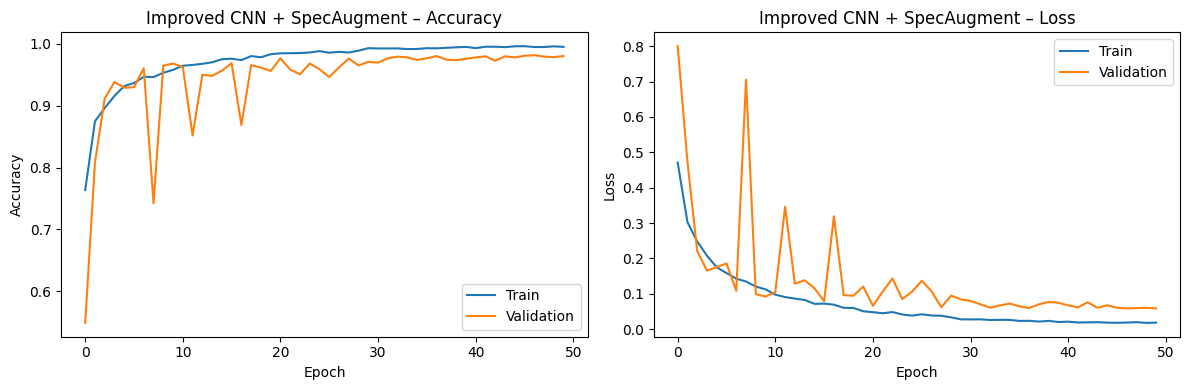


=== Improved CNN + SpecAugment ===
Accuracy:  0.7880
Recall:    0.9020
Precision: 0.7345
F1-score:  0.8097
AUC-ROC:   0.8897
EER:       0.1863
Bootstrap: 0.7883 [0.7598, 0.8162]


In [15]:
input_shape = X_train_norm.shape[1:]
inputs = layers.Input(shape=input_shape)
x = SpecAugment()(inputs)
x = layers.Conv2D(32, (3,3), padding="same", use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.MaxPooling2D((2,2))(x)
x = residual_block(x, 64)
x = layers.MaxPooling2D((2,2))(x)
x = residual_block(x, 128)
x = layers.MaxPooling2D((2,2))(x)
x = residual_block(x, 256)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

improved_cnn_aug = models.Model(inputs, outputs)
improved_cnn_aug.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
improved_cnn_aug.summary()

history_improved_aug = improved_cnn_aug.fit(
    X_train_norm, y_train,
    validation_data=(X_val_norm, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks("improved_cnn_aug_cqt")
)
plot_history(history_improved_aug, "Improved CNN + SpecAugment")
results_improved_aug = evaluate_model(improved_cnn_aug, X_test_norm, y_test, "Improved CNN + SpecAugment")

###Model 4: Mini-Xception

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 168, 126,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 168, 126,  │        288 │ input_layer_7[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 168, 126,  │        128 │ conv2d_11[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_14       │ (None, 168, 126,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_12 │ (None, 168, 126,  │      1,312 │ activation_14[0]… │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 168, 126,  │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_15       │ (None, 168, 126,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_13 │ (None, 168, 126,  │      1,312 │ activation_15[0]… │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 168, 126,  │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 84, 63,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 84, 63,    │          0 │ activation_14[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 84, 63,    │          0 │ max_pooling2d_9[… │
│                     │ 32)               │            │ max_pooling2d_10… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_14 │ (None, 84, 63,    │      2,336 │ add_6[0][0]       │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 84, 63,    │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_16       │ (None, 84, 63,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_15 │ (None, 84, 63,    │      4,672 │ activation_16[0]… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 84, 63,    │      2,048 │ add_6[0][0]     

 Total params: 187,009 (730.50 KB)

 Trainable params: 184,129 (719.25 KB)

 Non-trainable params: 2,880 (11.25 KB)

Epoch 1/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6312 - loss: 0.7597
Epoch 1: val_loss improved from None to 0.81718, saving model to /content/mini_xception_cqt.keras

Epoch 1: finished saving model to /content/mini_xception_cqt.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 60s 59ms/step - accuracy: 0.7141 - loss: 0.6152 - val_accuracy: 0.5655 - val_loss: 0.8172
Epoch 2/50
637/638 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8218 - loss: 0.3964
Epoch 2: val_loss improved from 0.81718 to 0.62773, saving model to /content/mini_xception_cqt.keras

Epoch 2: finished saving model to /content/mini_xception_cqt.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 27s 42ms/step - accuracy: 0.8401 - loss: 0.3642 - val_accuracy: 0.7669 - val_loss: 0.6277
Epoch 3/50
637/638 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8859 - loss: 0.2714
Epoch 3: val_loss did not improve from 0.62773
638/638 ━━━━━━━━━━━━━━━━━━━━ 27s 42ms/step - accuracy: 0.8882 - loss: 0.2692 - val_accuracy: 0.6399 - val_loss: 1.1273


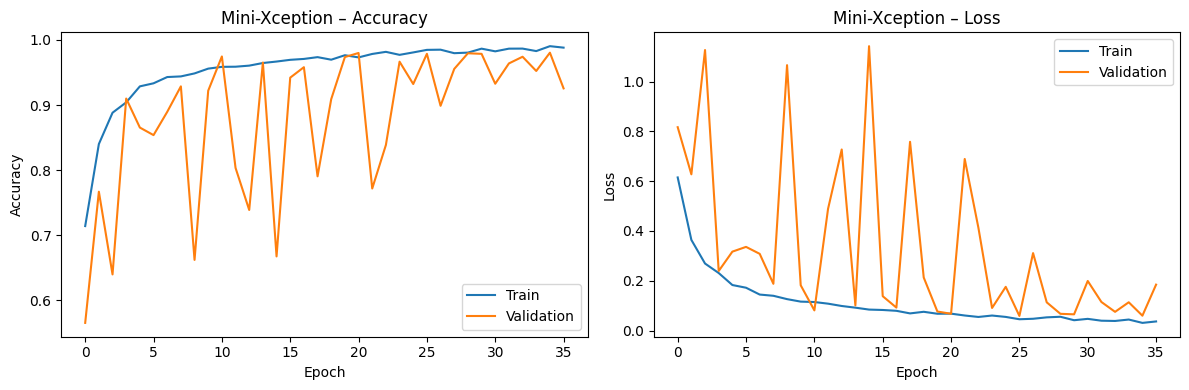


=== Mini-Xception ===
Accuracy:  0.7868
Recall:    0.9142
Precision: 0.7285
F1-score:  0.8109
AUC-ROC:   0.8824
EER:       0.2010
Bootstrap: 0.7869 [0.7586, 0.8162]


In [16]:
input_shape = X_train_norm.shape[1:]
inputs = layers.Input(shape=input_shape)
x = layers.Conv2D(32, (3,3), padding="same", use_bias=False)(inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

for filters in [32, 64, 128, 256]:
    residual = x
    x = layers.SeparableConv2D(filters, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.SeparableConv2D(filters, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2), padding="same")(x)
    if residual.shape[-1] != filters:
        residual = layers.Conv2D(filters, (1,1), padding="same", use_bias=False)(residual)
        residual = layers.BatchNormalization()(residual)
    residual = layers.MaxPooling2D((2,2), padding="same")(residual)
    x = layers.Add()([x, residual])

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

mini_xception = models.Model(inputs, outputs)
mini_xception.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
mini_xception.summary()

history_xception = mini_xception.fit(
    X_train_norm, y_train,
    validation_data=(X_val_norm, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks("mini_xception_cqt")
)
plot_history(history_xception, "Mini-Xception")
results_xception = evaluate_model(mini_xception, X_test_norm, y_test, "Mini-Xception")

###Model 5: MobileNet

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/50
633/638 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7723 - loss: 0.4641
Epoch 1: val_loss improved from None to 0.41605, saving model to /content/mobilenet_cqt.keras

Epoch 1: finished saving model to /content/mobilenet_cqt.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 40s 32ms/step - accuracy: 0.8191 - loss: 0.3917 - val_accuracy: 0.8088 - val_loss: 0.4160
Epoch 2/50
635/638 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8747 - loss: 0.2874
Epoch 2: val_loss improved from 0.41605 to 0.40685, saving model to /content/mobilenet_cqt.keras

Epoch 2: finished saving model to /content/mobilenet_cqt.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8826 - loss: 0.2760 - val_accuracy: 0.7977 - val_loss: 0.4069
Epoch 3/50
633/638 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8986 - loss: 0.2400
Epoch 3: val_loss improved from 0.40685 to 0.29198, saving model to /content/mobilenet_cqt.keras

Epoch 3: finished saving model to /conte

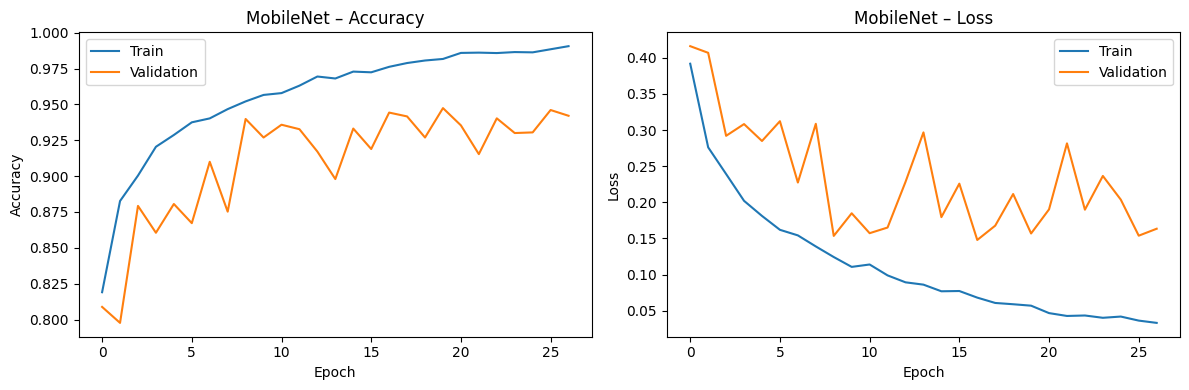


=== MobileNet ===
Accuracy:  0.7132
Recall:    0.7328
Precision: 0.7052
F1-score:  0.7188
AUC-ROC:   0.7807
EER:       0.2892
Bootstrap: 0.7130 [0.6814, 0.7439]


In [9]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

X_train_mob = mobilenet_preprocess(X_train_rgb96)
X_val_mob = mobilenet_preprocess(X_val_rgb96)
X_test_mob = mobilenet_preprocess(X_test_rgb96)

base = MobileNetV2(input_shape=(96, 96, 3), include_top=False, weights="imagenet")
base.trainable = True
for layer in base.layers[:-5]:
    layer.trainable = False

inputs  = layers.Input(shape=(96, 96, 3))
x       = base(inputs, training=False)
x       = layers.BatchNormalization()(x)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(128, activation="relu")(x)
x       = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

mobilenet = models.Model(inputs, outputs)
mobilenet.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

mobilenet.summary()

history_mobilenet = mobilenet.fit(
    X_train_mob, y_train,
    validation_data=(X_val_mob, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("mobilenet_cqt"),
    verbose=1
)

plot_history(history_mobilenet, "MobileNet")
results_mobilenet = evaluate_model(mobilenet, X_test_mob, y_test, "MobileNet")

###Model 6: VGG16

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,782,529 (56.39 MB)

 Trainable params: 7,146,241 (27.26 MB)

 Non-trainable params: 7,636,288 (29.13 MB)

Epoch 1/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.8155 - loss: 0.4015
Epoch 1: val_loss improved from None to 0.24122, saving model to /content/vgg16_cqt.keras

Epoch 1: finished saving model to /content/vgg16_cqt.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 112s 155ms/step - accuracy: 0.8794 - loss: 0.2766 - val_accuracy: 0.9131 - val_loss: 0.2412
Epoch 2/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.9439 - loss: 0.1418
Epoch 2: val_loss improved from 0.24122 to 0.08178, saving model to /content/vgg16_cqt.keras

Epoch 2: finished saving model to /content/vgg16_cqt.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 91s 143ms/step - accuracy: 0.9460 - loss: 0.1368 - val_accuracy: 0.9742 - val_loss: 0.0818
Epoch 3/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.9682 - loss: 0.0871
Epoch 3: val_loss did not improve from 0.08178
638/638 ━━━━━━━━━━━━━━━━━━━━ 91s 143ms/step - accuracy: 0.9672 - loss: 0.0860 - val_accuracy: 0.9069 - val_loss: 0.2271
Epoch 4/50
638/638 ━━━━━━

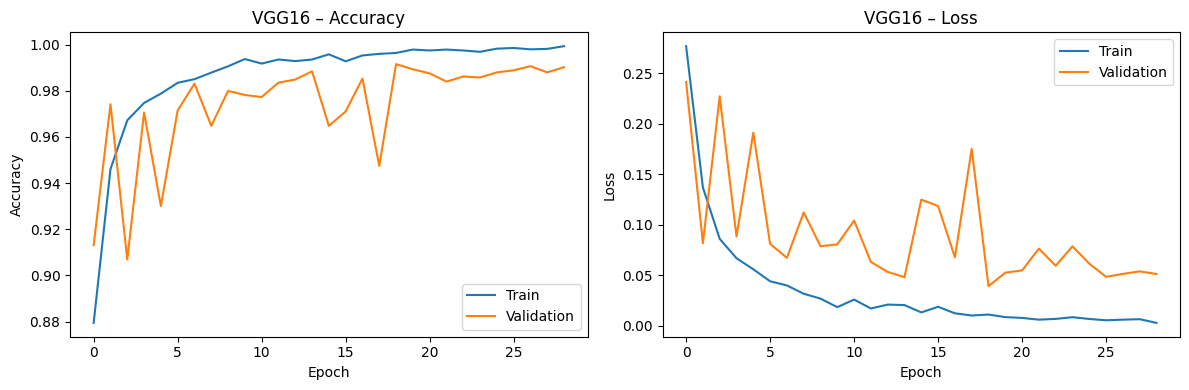


=== VGG16 ===
Accuracy:  0.7929
Recall:    0.9314
Precision: 0.7294
F1-score:  0.8181
AUC-ROC:   0.9092
EER:       0.1716
Bootstrap: 0.7926 [0.7610, 0.8199]


In [10]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess

X_train_vgg16 = vgg16_preprocess(X_train_vgg)
X_val_vgg16 = vgg16_preprocess(X_val_vgg)
X_test_vgg16 = vgg16_preprocess(X_test_vgg)

def build_vgg(vgg_class):
    base = vgg_class(include_top=False, weights="imagenet", input_shape=(224, 224, 3))
    for layer in base.layers:
        layer.trainable = False
    for layer in base.layers[-5:]:
        layer.trainable = True

    inputs  = layers.Input(shape=(224, 224, 3))
    x       = base(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dropout(0.4)(x)
    x       = layers.Dense(128, activation="relu")(x)
    x       = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    model.summary()
    return model

vgg16 = build_vgg(VGG16)

history_vgg16 = vgg16.fit(
    X_train_vgg16, y_train,
    validation_data=(X_val_vgg16, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks("vgg16_cqt")
)
plot_history(history_vgg16, "VGG16")
results_vgg16 = evaluate_model(vgg16, X_test_vgg16, y_test, "VGG16")

###Model 7: VGG19

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,092,225 (76.65 MB)

 Trainable params: 17,765,633 (67.77 MB)

 Non-trainable params: 2,326,592 (8.88 MB)

Epoch 1/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.7949 - loss: 0.4421
Epoch 1: val_loss improved from None to 0.57040, saving model to /content/vgg19_cqt.keras

Epoch 1: finished saving model to /content/vgg19_cqt.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 172s 253ms/step - accuracy: 0.8679 - loss: 0.3086 - val_accuracy: 0.7643 - val_loss: 0.5704
Epoch 2/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.9417 - loss: 0.1575
Epoch 2: val_loss improved from 0.57040 to 0.41625, saving model to /content/vgg19_cqt.keras

Epoch 2: finished saving model to /content/vgg19_cqt.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 157s 245ms/step - accuracy: 0.9459 - loss: 0.1474 - val_accuracy: 0.8111 - val_loss: 0.4163
Epoch 3/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.9517 - loss: 0.1258
Epoch 3: val_loss improved from 0.41625 to 0.32755, saving model to /content/vgg19_cqt.keras

Epoch 3: finished saving model to /content/vgg19_cqt.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 156s 245m

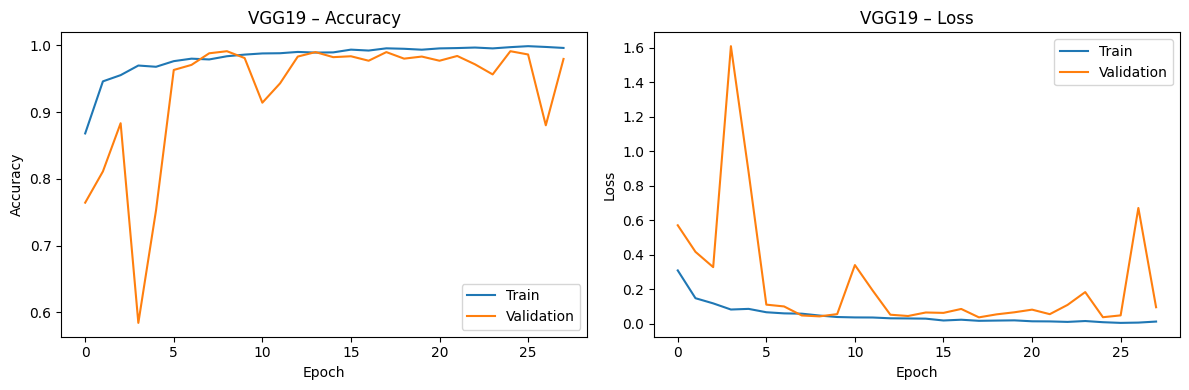


=== VGG19 ===
Accuracy:  0.8039
Recall:    0.9755
Precision: 0.7263
F1-score:  0.8326
AUC-ROC:   0.9638
EER:       0.0956
Bootstrap: 0.8040 [0.7782, 0.8321]


In [11]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input as vgg19_preprocess

X_train_vgg19 = vgg19_preprocess(X_train_vgg)
X_val_vgg19 = vgg19_preprocess(X_val_vgg)
X_test_vgg19 = vgg19_preprocess(X_test_vgg)

base = VGG19(include_top=False, weights="imagenet", input_shape=(224, 224, 3))
for layer in base.layers:
    layer.trainable = False
for layer in base.layers[-10:]:
    layer.trainable = True

inputs  = layers.Input(shape=(224, 224, 3))
x       = base(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(128, activation="relu")(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

vgg19 = models.Model(inputs, outputs)
vgg19.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
vgg19.summary()

history_vgg19 = vgg19.fit(
    X_train_vgg19, y_train,
    validation_data=(X_val_vgg19, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks("vgg19_cqt")
)
plot_history(history_vgg19, "VGG19")
results_vgg19 = evaluate_model(vgg19, X_test_vgg19, y_test, "VGG19")

###Model 8: Improved VGG19

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,090,177 (76.64 MB)

 Trainable params: 9,505,025 (36.26 MB)

 Non-trainable params: 10,585,152 (40.38 MB)

Epoch 1/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.7885 - loss: 0.7181
Epoch 1: val_loss improved from None to 0.52225, saving model to /content/vgg19_opt_cqt.keras

Epoch 1: finished saving model to /content/vgg19_opt_cqt.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 153s 219ms/step - accuracy: 0.8683 - loss: 0.3506 - val_accuracy: 0.7117 - val_loss: 0.5223
Epoch 2/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.9188 - loss: 0.1987
Epoch 2: val_loss improved from 0.52225 to 0.08869, saving model to /content/vgg19_opt_cqt.keras

Epoch 2: finished saving model to /content/vgg19_opt_cqt.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 136s 214ms/step - accuracy: 0.9463 - loss: 0.1393 - val_accuracy: 0.9670 - val_loss: 0.0887
Epoch 3/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.9749 - loss: 0.0747
Epoch 3: val_loss did not improve from 0.08869
638/638 ━━━━━━━━━━━━━━━━━━━━ 136s 213ms/step - accuracy: 0.9736 - loss: 0.0761 - val_accuracy: 0.9372 - val_loss: 0.1698
Epoch 4

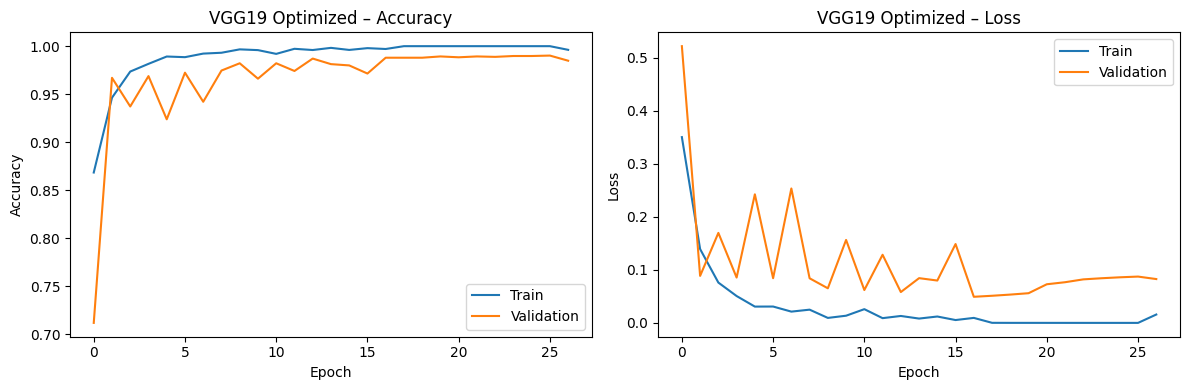


=== VGG19 Optimized ===
Accuracy:  0.8909
Recall:    0.9510
Precision: 0.8490
F1-score:  0.8971
AUC-ROC:   0.9603
EER:       0.1078
Bootstrap: 0.8910 [0.8701, 0.9118]


In [9]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input

def to_vgg_optimized_from_rgb(X_rgb):
    """Preprocess from already-resized RGB data (224x224x3)."""
    X_out = []
    for img in X_rgb:
        img_single = img[:, :, 0]
        img_single = np.flipud(img_single)
        img_stacked = np.stack([img_single, img_single, img_single], axis=-1)
        img_preprocessed = preprocess_input(img_stacked)
        X_out.append(img_preprocessed)
    return np.array(X_out, dtype=np.float32)

X_train_opt = to_vgg_optimized_from_rgb(X_train_vgg)
X_val_opt   = to_vgg_optimized_from_rgb(X_val_vgg)
X_test_opt  = to_vgg_optimized_from_rgb(X_test_vgg)

base_model = VGG19(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers:
    layer.trainable = False
for layer in base_model.layers[-5:]:
    layer.trainable = True

inputs  = layers.Input(shape=(224, 224, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(128, activation="relu")(x)
x       = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

vgg19_opt = models.Model(inputs, outputs)
vgg19_opt.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
vgg19_opt.summary()

history_vgg19_opt = vgg19_opt.fit(
    X_train_opt, y_train,
    validation_data=(X_val_opt, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("vgg19_opt_cqt")
)

plot_history(history_vgg19_opt, "VGG19 Optimized")
results_vgg19_opt = evaluate_model(vgg19_opt, X_test_opt, y_test, "VGG19 Optimized")

###MODEL 9: ResNet50

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,858,305 (91.01 MB)

 Trainable params: 4,732,161 (18.05 MB)

 Non-trainable params: 19,126,144 (72.96 MB)

Epoch 1/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.7760 - loss: 0.5405
Epoch 1: val_loss improved from None to 0.18934, saving model to /content/resnet_cqt.keras

Epoch 1: finished saving model to /content/resnet_cqt.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 68s 81ms/step - accuracy: 0.8310 - loss: 0.4231 - val_accuracy: 0.9278 - val_loss: 0.1893
Epoch 2/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9049 - loss: 0.2277
Epoch 2: val_loss improved from 0.18934 to 0.14953, saving model to /content/resnet_cqt.keras

Epoch 2: finished saving model to /content/resnet_cqt.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 42s 65ms/step - accuracy: 0.9097 - loss: 0.2235 - val_accuracy: 0.9479 - val_loss: 0.1495
Epoch 3/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9394 - loss: 0.1546
Epoch 3: val_loss improved from 0.14953 to 0.14752, saving model to /content/resnet_cqt.keras

Epoch 3: finished saving model to /content/resnet_cqt.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 41s 64ms/s

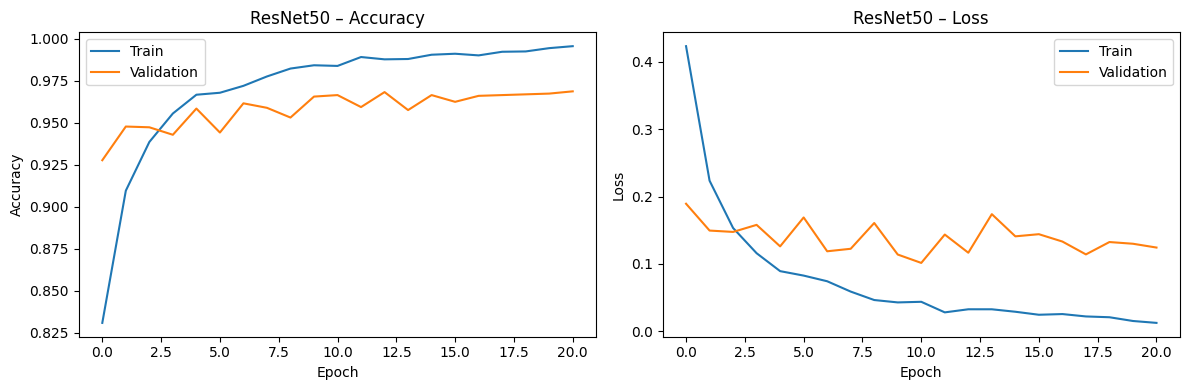


=== ResNet50 ===
Accuracy:  0.7402
Recall:    0.8505
Precision: 0.6968
F1-score:  0.7660
AUC-ROC:   0.8452
EER:       0.2426
Bootstrap: 0.7405 [0.7095, 0.7696]


In [12]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

X_train_resnet = resnet_preprocess(X_train_vgg)
X_val_resnet = resnet_preprocess(X_val_vgg)
X_test_resnet = resnet_preprocess(X_test_vgg)

base = ResNet50(include_top=False, weights="imagenet", input_shape=(224, 224, 3))
for layer in base.layers:
    layer.trainable = False
for layer in base.layers[-10:]:
    layer.trainable = True

inputs  = layers.Input(shape=(224, 224, 3))
x       = base(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(128, activation="relu")(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

resnet = models.Model(inputs, outputs)
resnet.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
resnet.summary()

history_resnet = resnet.fit(
    X_train_resnet, y_train,
    validation_data=(X_val_resnet, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("resnet_cqt")
)

plot_history(history_resnet, "ResNet50")
results_resnet = evaluate_model(resnet, X_test_resnet, y_test, "ResNet50")

#STFT

###Imports and parametre

In [3]:
import os, math, shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import librosa
import librosa.display
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, classification_report,
    f1_score, roc_auc_score, roc_curve,
    recall_score, precision_score
)
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint

SR              = 16000
DURATION        = 2.0
TARGET_LEN      = int(SR * DURATION)
N_FFT           = 1024
HOP_LENGTH      = 256
BATCH_SIZE      = 16
EPOCHS          = 50
INITIAL_LR      = 5e-5
PATIENCE        = 10

base_path  = "/content/for-rerec"
train_path = os.path.join(base_path, "training")
val_path   = os.path.join(base_path, "validation")
test_path  = os.path.join(base_path, "testing")

STFT Function & Data Loading

In [4]:
def create_stft(filepath):
    audio, _ = librosa.load(filepath, sr=SR, mono=True)
    if len(audio) < TARGET_LEN:
        audio = np.pad(audio, (0, TARGET_LEN - len(audio)))
    else:
        audio = audio[:TARGET_LEN]
    stft = np.abs(librosa.stft(audio, n_fft=N_FFT, hop_length=HOP_LENGTH))
    stft_db = librosa.amplitude_to_db(stft, ref=np.max)
    return stft_db.astype(np.float32)

def get_paths(split_path):
    real = sorted([
        os.path.join(split_path, "real", f)
        for f in os.listdir(os.path.join(split_path, "real"))
        if f.endswith(".wav")
    ])
    fake = sorted([
        os.path.join(split_path, "fake", f)
        for f in os.listdir(os.path.join(split_path, "fake"))
        if f.endswith(".wav")
    ])
    return real, fake

def load_split(split_path):
    real, fake = get_paths(split_path)
    X, y = [], []
    for fp in real:
        X.append(create_stft(fp))
        y.append(1)
    for fp in fake:
        X.append(create_stft(fp))
        y.append(0)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

print("Loading STFT data...")
X_train, y_train = load_split(train_path)
X_val, y_val = load_split(val_path)
X_test, y_test = load_split(test_path)

print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)
print(f"Data range: {X_train.min():.2f} to {X_train.max():.2f}")

Loading STFT data...
Train: (10208, 513, 126)
Val:   (2244, 513, 126)
Test:  (816, 513, 126)
Data range: -80.00 to 0.00


RGB Conversion

In [5]:
def to_rgb_resized(X, size):
    """Convert grayscale spectrograms to RGB and resize."""
    results = []
    for spec in X:
        spec_rgb = np.stack([spec, spec, spec], axis=-1)
        spec_resized = tf.image.resize(spec_rgb, (size, size)).numpy()
        results.append(spec_resized)
    return np.array(results, dtype=np.float32)

print("Converting to RGB...")
X_train_rgb96 = to_rgb_resized(X_train, 96)
X_val_rgb96   = to_rgb_resized(X_val, 96)
X_test_rgb96  = to_rgb_resized(X_test, 96)

X_train_vgg = to_rgb_resized(X_train, 224)
X_val_vgg   = to_rgb_resized(X_val, 224)
X_test_vgg  = to_rgb_resized(X_test, 224)

print("RGB 96 (MobileNet):", X_train_rgb96.shape)
print("VGG 224 (VGG16/VGG19/ResNet50):", X_train_vgg.shape)
print(f"RGB96 data range: {X_train_rgb96.min():.2f} to {X_train_rgb96.max():.2f}")

Converting to RGB...
RGB 96 (MobileNet): (10208, 96, 96, 3)
VGG 224 (VGG16/VGG19/ResNet50): (10208, 224, 224, 3)
RGB96 data range: -80.00 to -0.04


Z-Score Normalisering

In [6]:
print("Z-score normalizing for custom CNNs...")

mean = X_train.mean(axis=(0, 1, 2), keepdims=True)
std  = X_train.std(axis=(0, 1, 2), keepdims=True) + 1e-8

X_train_norm = (X_train - mean) / std
X_val_norm   = (X_val   - mean) / std
X_test_norm  = (X_test  - mean) / std

X_train_norm = X_train_norm[..., np.newaxis]
X_val_norm   = X_val_norm[..., np.newaxis]
X_test_norm  = X_test_norm[..., np.newaxis]

print("Normalized train shape:", X_train_norm.shape)
print("Normalized val shape:  ", X_val_norm.shape)
print("Normalized test shape: ", X_test_norm.shape)

print(f"\nZ-scored data - Mean: {X_train_norm.mean():.6f}, Std: {X_train_norm.std():.6f}")
print(f"Z-scored range: {X_train_norm.min():.2f} to {X_train_norm.max():.2f}")

Z-score normalizing for custom CNNs...
Normalized train shape: (10208, 513, 126, 1)
Normalized val shape:   (2244, 513, 126, 1)
Normalized test shape:  (816, 513, 126, 1)

Z-scored data - Mean: 0.000051, Std: 0.999998
Z-scored range: -0.99 to 4.28


Helper Functions

In [7]:
class CosineAnnealingScheduler(Callback):
    def __init__(self, T_max, eta_max, eta_min=1e-6, verbose=0):
        super().__init__()
        self.T_max   = T_max
        self.eta_max = eta_max
        self.eta_min = eta_min
        self.verbose = verbose

    def on_epoch_begin(self, epoch, logs=None):
        lr = self.eta_min + (self.eta_max - self.eta_min) * (
            1 + math.cos(math.pi * epoch / self.T_max)
        ) / 2
        self.model.optimizer.learning_rate.assign(lr)
        if self.verbose:
            print(f"  LR: {lr:.2e}")

def get_callbacks(model_name):
    return [
        EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True, verbose=1),
        CosineAnnealingScheduler(T_max=EPOCHS, eta_max=INITIAL_LR, eta_min=1e-6),
        ModelCheckpoint(f"/content/{model_name}.keras", monitor="val_loss", save_best_only=True, verbose=1)
    ]

def equal_error_rate(y_true, y_scores):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    fnr = 1 - tpr
    idx = np.argmin(np.abs(fpr - fnr))
    return float(fpr[idx])

def bootstrap_ci(y_true, y_scores, n=1000, alpha=0.05):
    accs = []
    n_samples = len(y_true)
    for _ in range(n):
        idx = np.random.randint(0, n_samples, size=n_samples)
        y_b = y_true[idx]
        y_s = y_scores[idx]
        y_p = (y_s >= 0.5).astype(int)
        accs.append(accuracy_score(y_b, y_p))
    lower = np.percentile(accs, 100 * alpha / 2)
    upper = np.percentile(accs, 100 * (1 - alpha / 2))
    return np.mean(accs), lower, upper

def evaluate_model(model, X, y, model_name):
    y_prob  = model.predict(X, verbose=0).ravel()
    y_pred  = (y_prob >= 0.5).astype(int)
    acc     = accuracy_score(y, y_pred)
    recall  = recall_score(y, y_pred)
    prec    = precision_score(y, y_pred, zero_division=0)
    f1      = f1_score(y, y_pred)
    auc     = roc_auc_score(y, y_prob)
    eer     = equal_error_rate(y, y_prob)
    mean_acc, ci_low, ci_high = bootstrap_ci(y, y_prob)

    print(f"\n=== {model_name} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"AUC-ROC:   {auc:.4f}")
    print(f"EER:       {eer:.4f}")
    print(f"Bootstrap: {mean_acc:.4f} [{ci_low:.4f}, {ci_high:.4f}]")

    return {
        "model": model_name, "accuracy": acc, "recall": recall,
        "precision": prec, "f1": f1, "auc": auc, "eer": eer,
        "ci_low": ci_low, "ci_high": ci_high
    }

def plot_history(history, model_name):
    best_val_acc = max(history.history["val_accuracy"])
    print(f"Best val accuracy ({model_name}): {best_val_acc:.4f}")
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train")
    plt.plot(history.history["val_accuracy"], label="Validation")
    plt.title(f"{model_name} – Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train")
    plt.plot(history.history["val_loss"], label="Validation")
    plt.title(f"{model_name} – Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
    plt.tight_layout(); plt.show()

SpecAugment & Residual Block

In [8]:
class SpecAugment(layers.Layer):
    def __init__(self, freq_mask=10, time_mask=15, **kwargs):
        super().__init__(**kwargs)
        self.freq_mask = freq_mask
        self.time_mask = time_mask

    def call(self, x, training=None):
        if not training:
            return x
        freq = tf.shape(x)[1]
        time = tf.shape(x)[2]

        f  = tf.random.uniform([], 0, self.freq_mask, dtype=tf.int32)
        f0 = tf.random.uniform([], 0, freq - f, dtype=tf.int32)
        freq_mask = 1.0 - tf.cast(
            tf.sequence_mask(f, freq) & ~tf.sequence_mask(f0, freq),
            dtype=x.dtype
        )
        freq_mask = tf.reshape(freq_mask, [1, freq, 1, 1])
        x = x * freq_mask

        t  = tf.random.uniform([], 0, self.time_mask, dtype=tf.int32)
        t0 = tf.random.uniform([], 0, time - t, dtype=tf.int32)
        time_mask = 1.0 - tf.cast(
            tf.sequence_mask(t, time) & ~tf.sequence_mask(t0, time),
            dtype=x.dtype
        )
        time_mask = tf.reshape(time_mask, [1, 1, time, 1])
        x = x * time_mask
        return x

def residual_block(x, filters):
    shortcut = x
    x = layers.SeparableConv2D(filters, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.SeparableConv2D(filters, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1,1), padding="same", use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)
    return x

###Model 1 - Simple CNN

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 513, 126, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 256, 63, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 256, 63, 32)    │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 128, 31, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 31, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 61440)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,932,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,955,585 (15.09 MB)

 Trainable params: 3,955,585 (15.09 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6836 - loss: 0.5834
Epoch 1: val_loss improved from None to 0.37172, saving model to /content/simple_cnn_stft.keras

Epoch 1: finished saving model to /content/simple_cnn_stft.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - accuracy: 0.7618 - loss: 0.4945 - val_accuracy: 0.8365 - val_loss: 0.3717
Epoch 2/50
637/638 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8650 - loss: 0.3330
Epoch 2: val_loss improved from 0.37172 to 0.26972, saving model to /content/simple_cnn_stft.keras

Epoch 2: finished saving model to /content/simple_cnn_stft.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.8779 - loss: 0.3116 - val_accuracy: 0.8913 - val_loss: 0.2697
Epoch 3/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8948 - loss: 0.2686
Epoch 3: val_loss improved from 0.26972 to 0.21481, saving model to /content/simple_cnn_stft.keras

Epoch 3: finished saving model to /content/simple_cnn_stft.keras
638/638 ━

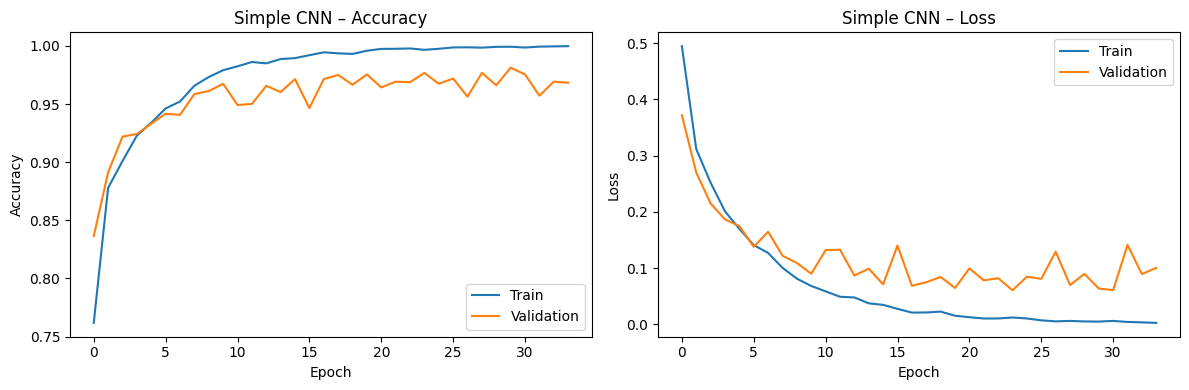


=== Simple CNN ===
Accuracy:  0.7402
Recall:    0.9338
Precision: 0.6731
F1-score:  0.7823
AUC-ROC:   0.8168
EER:       0.2426
Bootstrap: 0.7406 [0.7108, 0.7708]


In [9]:
input_shape = X_train_norm.shape[1:]
simple_cnn = models.Sequential([
    layers.Input(shape=input_shape),
    layers.Conv2D(16, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

simple_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
simple_cnn.summary()

history_simple = simple_cnn.fit(
    X_train_norm, y_train,
    validation_data=(X_val_norm, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks("simple_cnn_stft")
)
plot_history(history_simple, "Simple CNN")
results_simple = evaluate_model(simple_cnn, X_test_norm, y_test, "Simple CNN")

###Model 2 - Improved CNN

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 513, 126,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 513, 126,  │        288 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 513, 126,  │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 513, 126,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 256, 63,   │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 256, 63,   │      2,336 │ max_pooling2d_3[… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 63,   │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 63,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 256, 63,   │      4,672 │ activation_1[0][… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 256, 63,   │      2,048 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 63,   │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 63,   │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256, 63,   │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 256, 63,   │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 128, 31,   │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 128, 31,   │      8,768 │ max_pooling2d_4[… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 31,   │        512 │ separable_conv2d

 Total params: 184,129 (719.25 KB)

 Trainable params: 181,377 (708.50 KB)

 Non-trainable params: 2,752 (10.75 KB)

Epoch 1/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.6569 - loss: 0.6405
Epoch 1: val_loss improved from None to 1.12830, saving model to /content/improved_cnn_stft.keras

Epoch 1: finished saving model to /content/improved_cnn_stft.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 74s 82ms/step - accuracy: 0.7381 - loss: 0.5258 - val_accuracy: 0.4951 - val_loss: 1.1283
Epoch 2/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.8403 - loss: 0.3616
Epoch 2: val_loss improved from 1.12830 to 0.43721, saving model to /content/improved_cnn_stft.keras

Epoch 2: finished saving model to /content/improved_cnn_stft.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 42s 66ms/step - accuracy: 0.8599 - loss: 0.3278 - val_accuracy: 0.8160 - val_loss: 0.4372
Epoch 3/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8973 - loss: 0.2484
Epoch 3: val_loss improved from 0.43721 to 0.22652, saving model to /content/improved_cnn_stft.keras

Epoch 3: finished saving model to /content/improved_cnn_stft.ker

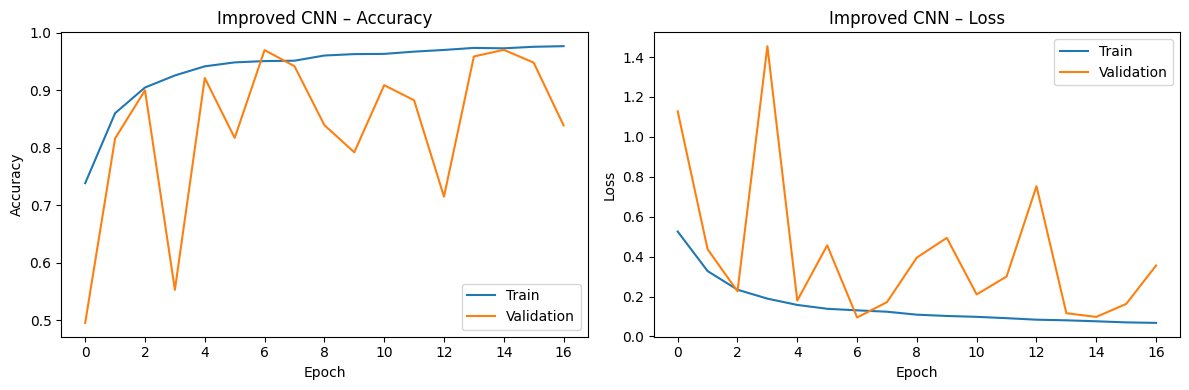


=== Improved CNN ===
Accuracy:  0.6642
Recall:    0.8358
Precision: 0.6223
F1-score:  0.7134
AUC-ROC:   0.7762
EER:       0.2868
Bootstrap: 0.6631 [0.6287, 0.6949]


In [10]:
input_shape = X_train_norm.shape[1:]
inputs = layers.Input(shape=input_shape)
x = layers.Conv2D(32, (3,3), padding="same", use_bias=False)(inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.MaxPooling2D((2,2))(x)
x = residual_block(x, 64)
x = layers.MaxPooling2D((2,2))(x)
x = residual_block(x, 128)
x = layers.MaxPooling2D((2,2))(x)
x = residual_block(x, 256)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

improved_cnn = models.Model(inputs, outputs)
improved_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
improved_cnn.summary()

history_improved = improved_cnn.fit(
    X_train_norm, y_train,
    validation_data=(X_val_norm, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks("improved_cnn_stft")
)
plot_history(history_improved, "Improved CNN")
results_improved = evaluate_model(improved_cnn, X_test_norm, y_test, "Improved CNN")

###Model 3 - Improved CNN + SpecAugment

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 513, 126,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spec_augment        │ (None, 513, 126,  │          0 │ input_layer_2[0]… │
│ (SpecAugment)       │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 513, 126,  │        288 │ spec_augment[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 513, 126,  │        128 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 513, 126,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 256, 63,   │          0 │ activation_7[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_6  │ (None, 256, 63,   │      2,336 │ max_pooling2d_6[… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 63,   │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 256, 63,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_7  │ (None, 256, 63,   │      4,672 │ activation_8[0][… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 256, 63,   │      2,048 │ max_pooling2d_6[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 63,   │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 63,   │        256 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 256, 63,   │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 256, 63,   │          0 │ add_3[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 128, 31,   │          0 │ activation_9[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_8  │ (None, 128, 31,   │      8,768 │ max_pooling2d_7[

 Total params: 184,129 (719.25 KB)

 Trainable params: 181,377 (708.50 KB)

 Non-trainable params: 2,752 (10.75 KB)

Epoch 1/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.6998 - loss: 0.5716
Epoch 1: val_loss improved from None to 0.64243, saving model to /content/improved_cnn_aug_stft.keras

Epoch 1: finished saving model to /content/improved_cnn_aug_stft.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 63s 77ms/step - accuracy: 0.7652 - loss: 0.4866 - val_accuracy: 0.6404 - val_loss: 0.6424
Epoch 2/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.8590 - loss: 0.3348
Epoch 2: val_loss improved from 0.64243 to 0.24357, saving model to /content/improved_cnn_aug_stft.keras

Epoch 2: finished saving model to /content/improved_cnn_aug_stft.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.8704 - loss: 0.3116 - val_accuracy: 0.8975 - val_loss: 0.2436
Epoch 3/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8905 - loss: 0.2540
Epoch 3: val_loss did not improve from 0.24357
638/638 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.9005 - loss: 0.2408 - val_accuracy: 0.8832 - v

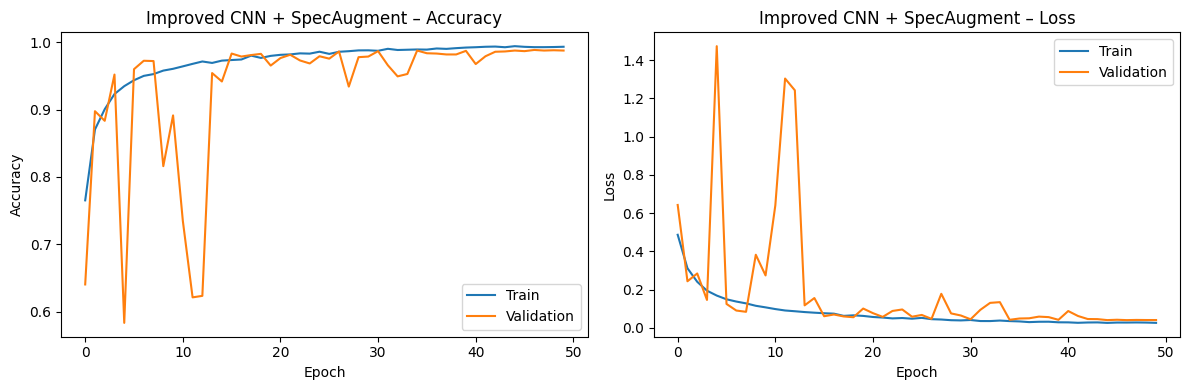


=== Improved CNN + SpecAugment ===
Accuracy:  0.7610
Recall:    0.9118
Precision: 0.7006
F1-score:  0.7923
AUC-ROC:   0.8590
EER:       0.2157
Bootstrap: 0.7616 [0.7328, 0.7892]


In [11]:
input_shape = X_train_norm.shape[1:]
inputs = layers.Input(shape=input_shape)
x = SpecAugment()(inputs)
x = layers.Conv2D(32, (3,3), padding="same", use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.MaxPooling2D((2,2))(x)
x = residual_block(x, 64)
x = layers.MaxPooling2D((2,2))(x)
x = residual_block(x, 128)
x = layers.MaxPooling2D((2,2))(x)
x = residual_block(x, 256)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

improved_cnn_aug = models.Model(inputs, outputs)
improved_cnn_aug.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
improved_cnn_aug.summary()

history_improved_aug = improved_cnn_aug.fit(
    X_train_norm, y_train,
    validation_data=(X_val_norm, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks("improved_cnn_aug_stft")
)
plot_history(history_improved_aug, "Improved CNN + SpecAugment")
results_improved_aug = evaluate_model(improved_cnn_aug, X_test_norm, y_test, "Improved CNN + SpecAugment")

###Model 4 - Mini-Xception

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 513, 126,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 513, 126,  │        288 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 513, 126,  │        128 │ conv2d_11[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_14       │ (None, 513, 126,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_12 │ (None, 513, 126,  │      1,312 │ activation_14[0]… │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 513, 126,  │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_15       │ (None, 513, 126,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_13 │ (None, 513, 126,  │      1,312 │ activation_15[0]… │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 513, 126,  │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 257, 63,   │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 257, 63,   │          0 │ activation_14[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 257, 63,   │          0 │ max_pooling2d_9[… │
│                     │ 32)               │            │ max_pooling2d_10… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_14 │ (None, 257, 63,   │      2,336 │ add_6[0][0]       │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 257, 63,   │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_16       │ (None, 257, 63,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_15 │ (None, 257, 63,   │      4,672 │ activation_16[0]… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 257, 63,   │      2,048 │ add_6[0][0]     

 Total params: 187,009 (730.50 KB)

 Trainable params: 184,129 (719.25 KB)

 Non-trainable params: 2,880 (11.25 KB)

Epoch 1/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.6513 - loss: 0.7131
Epoch 1: val_loss improved from None to 2.26956, saving model to /content/mini_xception_stft.keras

Epoch 1: finished saving model to /content/mini_xception_stft.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 117s 141ms/step - accuracy: 0.7249 - loss: 0.5811 - val_accuracy: 0.4906 - val_loss: 2.2696
Epoch 2/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.8366 - loss: 0.3801
Epoch 2: val_loss improved from 2.26956 to 0.26487, saving model to /content/mini_xception_stft.keras

Epoch 2: finished saving model to /content/mini_xception_stft.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 78s 122ms/step - accuracy: 0.8448 - loss: 0.3591 - val_accuracy: 0.8881 - val_loss: 0.2649
Epoch 3/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.8815 - loss: 0.2826
Epoch 3: val_loss did not improve from 0.26487
638/638 ━━━━━━━━━━━━━━━━━━━━ 79s 124ms/step - accuracy: 0.8905 - loss: 0.2651 - val_accuracy: 0.7451 - val_lo

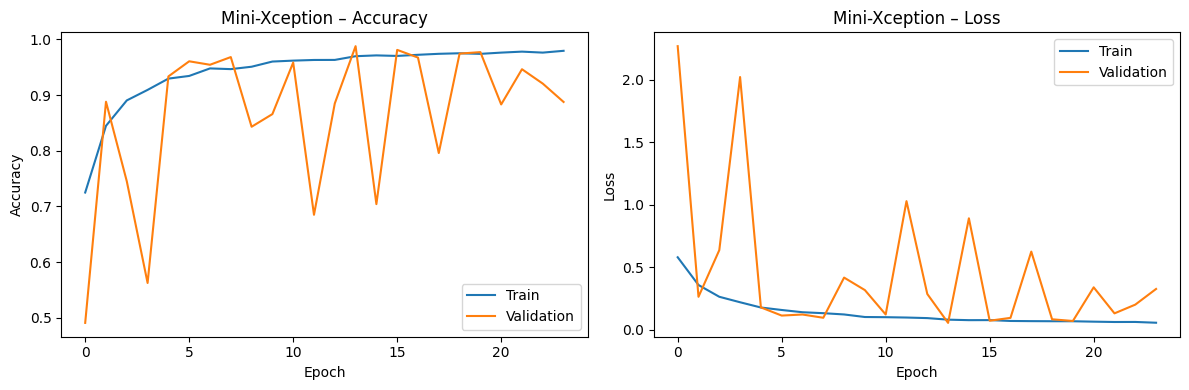


=== Mini-Xception ===
Accuracy:  0.7353
Recall:    0.8162
Precision: 0.7025
F1-score:  0.7551
AUC-ROC:   0.8237
EER:       0.2475
Bootstrap: 0.7355 [0.7059, 0.7635]


In [12]:
input_shape = X_train_norm.shape[1:]
inputs = layers.Input(shape=input_shape)
x = layers.Conv2D(32, (3,3), padding="same", use_bias=False)(inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

for filters in [32, 64, 128, 256]:
    residual = x
    x = layers.SeparableConv2D(filters, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.SeparableConv2D(filters, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2), padding="same")(x)
    if residual.shape[-1] != filters:
        residual = layers.Conv2D(filters, (1,1), padding="same", use_bias=False)(residual)
        residual = layers.BatchNormalization()(residual)
    residual = layers.MaxPooling2D((2,2), padding="same")(residual)
    x = layers.Add()([x, residual])

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

mini_xception = models.Model(inputs, outputs)
mini_xception.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
mini_xception.summary()

history_xception = mini_xception.fit(
    X_train_norm, y_train,
    validation_data=(X_val_norm, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks("mini_xception_stft")
)
plot_history(history_xception, "Mini-Xception")
results_xception = evaluate_model(mini_xception, X_test_norm, y_test, "Mini-Xception")

###Model 5 - MobileNet

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 3, 3, 1280)     │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,201 (9.26 MB)

 Trainable params: 886,657 (3.38 MB)

 Non-trainable params: 1,540,544 (5.88 MB)

Epoch 1/50
632/638 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7621 - loss: 0.4716
Epoch 1: val_loss improved from None to 0.50733, saving model to /content/mobilenet_stft.keras

Epoch 1: finished saving model to /content/mobilenet_stft.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 36s 31ms/step - accuracy: 0.8204 - loss: 0.3879 - val_accuracy: 0.8061 - val_loss: 0.5073
Epoch 2/50
636/638 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8775 - loss: 0.2941
Epoch 2: val_loss improved from 0.50733 to 0.44256, saving model to /content/mobilenet_stft.keras

Epoch 2: finished saving model to /content/mobilenet_stft.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8852 - loss: 0.2781 - val_accuracy: 0.7634 - val_loss: 0.4426
Epoch 3/50
637/638 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9071 - loss: 0.2330
Epoch 3: val_loss did not improve from 0.44256
638/638 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9096 - loss: 0.2297 - val_accuracy: 0.6751 - val_loss: 0.6064
Epoch 4/50
637/638 

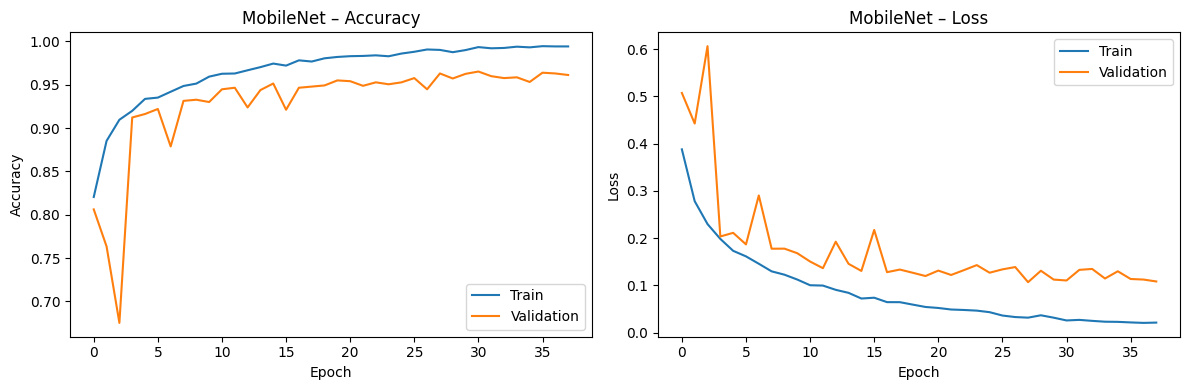


=== MobileNet ===
Accuracy:  0.5600
Recall:    0.8725
Precision: 0.5370
F1-score:  0.6648
AUC-ROC:   0.6421
EER:       0.4118
Bootstrap: 0.5599 [0.5282, 0.5931]


In [13]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

X_train_mob = mobilenet_preprocess(X_train_rgb96)
X_val_mob = mobilenet_preprocess(X_val_rgb96)
X_test_mob = mobilenet_preprocess(X_test_rgb96)

base = MobileNetV2(input_shape=(96, 96, 3), include_top=False, weights="imagenet")
base.trainable = True
for layer in base.layers[:-5]:
    layer.trainable = False

inputs  = layers.Input(shape=(96, 96, 3))
x       = base(inputs, training=False)
x       = layers.BatchNormalization()(x)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(128, activation="relu")(x)
x       = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

mobilenet = models.Model(inputs, outputs)
mobilenet.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
mobilenet.summary()

history_mobilenet = mobilenet.fit(
    X_train_mob, y_train,
    validation_data=(X_val_mob, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("mobilenet_stft"),
    verbose=1
)

plot_history(history_mobilenet, "MobileNet")
results_mobilenet = evaluate_model(mobilenet, X_test_mob, y_test, "MobileNet")

###Model 6 - VGG16

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,782,529 (56.39 MB)

 Trainable params: 7,146,241 (27.26 MB)

 Non-trainable params: 7,636,288 (29.13 MB)

Epoch 1/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.8360 - loss: 0.3483
Epoch 1: val_loss improved from None to 0.06010, saving model to /content/vgg16_stft.keras

Epoch 1: finished saving model to /content/vgg16_stft.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 121s 166ms/step - accuracy: 0.9056 - loss: 0.2231 - val_accuracy: 0.9831 - val_loss: 0.0601
Epoch 2/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.9705 - loss: 0.0858
Epoch 2: val_loss did not improve from 0.06010
638/638 ━━━━━━━━━━━━━━━━━━━━ 98s 153ms/step - accuracy: 0.9718 - loss: 0.0827 - val_accuracy: 0.9568 - val_loss: 0.1134
Epoch 3/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.9813 - loss: 0.0517
Epoch 3: val_loss did not improve from 0.06010
638/638 ━━━━━━━━━━━━━━━━━━━━ 98s 153ms/step - accuracy: 0.9798 - loss: 0.0572 - val_accuracy: 0.8538 - val_loss: 0.3634
Epoch 4/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.9854 - loss: 0.0410
Epoch 4: val_loss did not improve from 0.

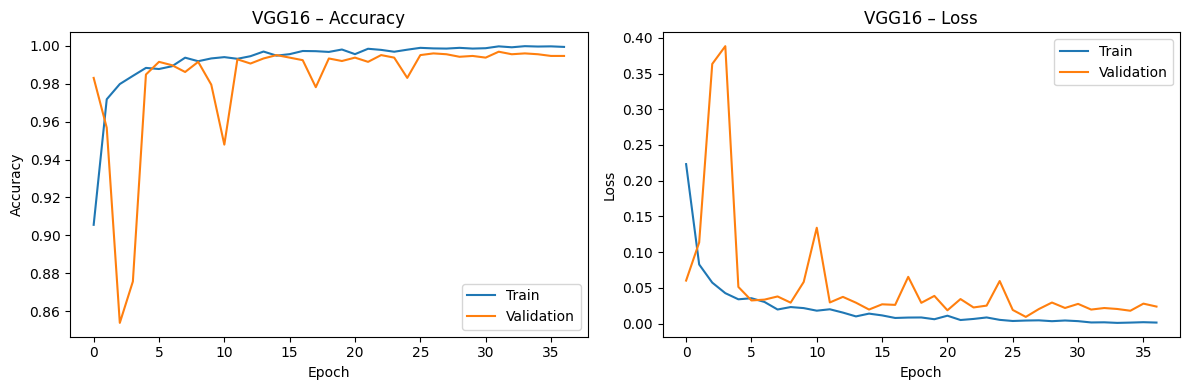


=== VGG16 ===
Accuracy:  0.5049
Recall:    0.9951
Precision: 0.5025
F1-score:  0.6678
AUC-ROC:   0.6248
EER:       0.4020
Bootstrap: 0.5045 [0.4706, 0.5404]


In [17]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess

X_train_vgg16 = vgg16_preprocess(X_train_vgg)
X_val_vgg16 = vgg16_preprocess(X_val_vgg)
X_test_vgg16 = vgg16_preprocess(X_test_vgg)

def build_vgg(vgg_class):
    base = vgg_class(include_top=False, weights="imagenet", input_shape=(224, 224, 3))
    for layer in base.layers:
        layer.trainable = False
    for layer in base.layers[-5:]:
        layer.trainable = True

    inputs  = layers.Input(shape=(224, 224, 3))
    x       = base(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dropout(0.4)(x)
    x       = layers.Dense(128, activation="relu")(x)
    x       = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    model.summary()
    return model

vgg16 = build_vgg(VGG16)

history_vgg16 = vgg16.fit(
    X_train_vgg16, y_train,
    validation_data=(X_val_vgg16, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks("vgg16_stft")
)

plot_history(history_vgg16, "VGG16")
results_vgg16 = evaluate_model(vgg16, X_test_vgg16, y_test, "VGG16")

###Model 7 - VGG19

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,092,225 (76.65 MB)

 Trainable params: 17,765,633 (67.77 MB)

 Non-trainable params: 2,326,592 (8.88 MB)

Epoch 1/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.8317 - loss: 0.3642
Epoch 1: val_loss improved from None to 1.39566, saving model to /content/vgg19_stft.keras

Epoch 1: finished saving model to /content/vgg19_stft.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 185s 271ms/step - accuracy: 0.9021 - loss: 0.2388 - val_accuracy: 0.6168 - val_loss: 1.3957
Epoch 2/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.9658 - loss: 0.1006
Epoch 2: val_loss improved from 1.39566 to 0.05768, saving model to /content/vgg19_stft.keras

Epoch 2: finished saving model to /content/vgg19_stft.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 169s 265ms/step - accuracy: 0.9687 - loss: 0.0919 - val_accuracy: 0.9817 - val_loss: 0.0577
Epoch 3/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.9774 - loss: 0.0650
Epoch 3: val_loss did not improve from 0.05768
638/638 ━━━━━━━━━━━━━━━━━━━━ 167s 262ms/step - accuracy: 0.9762 - loss: 0.0668 - val_accuracy: 0.5299 - val_loss: 2.5924
Epoch 4/50
638/638 

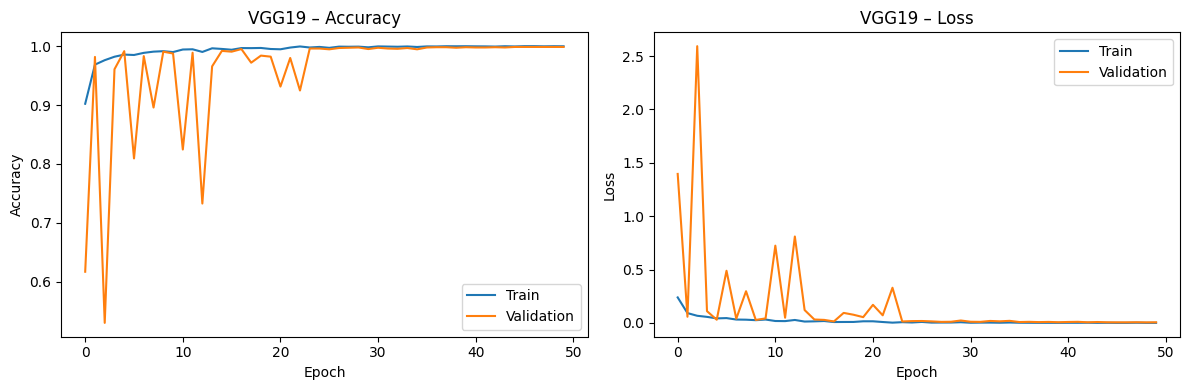


=== VGG19 ===
Accuracy:  0.5539
Recall:    0.9975
Precision: 0.5286
F1-score:  0.6910
AUC-ROC:   0.8508
EER:       0.2475
Bootstrap: 0.5533 [0.5208, 0.5858]


In [18]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input as vgg19_preprocess

X_train_vgg19 = vgg19_preprocess(X_train_vgg)
X_val_vgg19 = vgg19_preprocess(X_val_vgg)
X_test_vgg19 = vgg19_preprocess(X_test_vgg)

base = VGG19(include_top=False, weights="imagenet", input_shape=(224, 224, 3))
for layer in base.layers:
    layer.trainable = False
for layer in base.layers[-10:]:
    layer.trainable = True

inputs  = layers.Input(shape=(224, 224, 3))
x       = base(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(128, activation="relu")(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

vgg19 = models.Model(inputs, outputs)
vgg19.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
vgg19.summary()

history_vgg19 = vgg19.fit(
    X_train_vgg19, y_train,
    validation_data=(X_val_vgg19, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks("vgg19_stft")
)
plot_history(history_vgg19, "VGG19")
results_vgg19 = evaluate_model(vgg19, X_test_vgg19, y_test, "VGG19")

###Model 8: Improved VGG19

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,090,177 (76.64 MB)

 Trainable params: 9,505,025 (36.26 MB)

 Non-trainable params: 10,585,152 (40.38 MB)

Epoch 1/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.8165 - loss: 0.4619
Epoch 1: val_loss improved from None to 0.06375, saving model to /content/vgg19_opt_stft.keras

Epoch 1: finished saving model to /content/vgg19_opt_stft.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 137s 208ms/step - accuracy: 0.8955 - loss: 0.2611 - val_accuracy: 0.9791 - val_loss: 0.0638
Epoch 2/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.9741 - loss: 0.0746
Epoch 2: val_loss did not improve from 0.06375
638/638 ━━━━━━━━━━━━━━━━━━━━ 127s 199ms/step - accuracy: 0.9724 - loss: 0.0804 - val_accuracy: 0.9808 - val_loss: 0.0671
Epoch 3/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.9865 - loss: 0.0435
Epoch 3: val_loss did not improve from 0.06375
638/638 ━━━━━━━━━━━━━━━━━━━━ 127s 200ms/step - accuracy: 0.9837 - loss: 0.0504 - val_accuracy: 0.9603 - val_loss: 0.1172
Epoch 4/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.9890 - loss: 0.0291
Epoch 4: val_loss did not impro

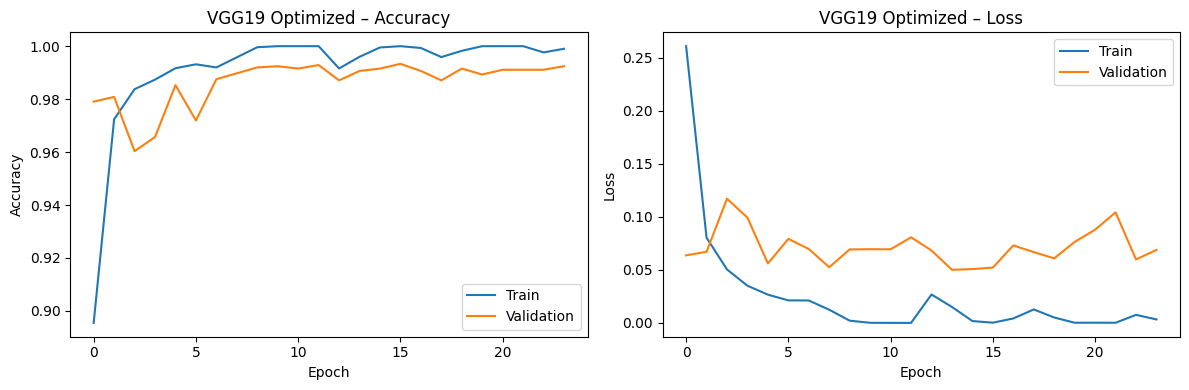


=== VGG19 Optimized ===
Accuracy:  0.7230
Recall:    0.9289
Precision: 0.6580
F1-score:  0.7703
AUC-ROC:   0.8342
EER:       0.2402
Bootstrap: 0.7225 [0.6936, 0.7537]


In [19]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input

def to_vgg_optimized_from_rgb(X_rgb):
    """Preprocess from already-resized RGB data (224x224x3)."""
    X_out = []
    for img in X_rgb:
        img_single = img[:, :, 0]
        img_single = np.flipud(img_single)
        img_stacked = np.stack([img_single, img_single, img_single], axis=-1)
        img_preprocessed = preprocess_input(img_stacked)
        X_out.append(img_preprocessed)
    return np.array(X_out, dtype=np.float32)

X_train_opt = to_vgg_optimized_from_rgb(X_train_vgg)
X_val_opt   = to_vgg_optimized_from_rgb(X_val_vgg)
X_test_opt  = to_vgg_optimized_from_rgb(X_test_vgg)

base_model = VGG19(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers:
    layer.trainable = False
for layer in base_model.layers[-5:]:
    layer.trainable = True

inputs  = layers.Input(shape=(224, 224, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(128, activation="relu")(x)
x       = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

vgg19_opt = models.Model(inputs, outputs)
vgg19_opt.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
vgg19_opt.summary()

history_vgg19_opt = vgg19_opt.fit(
    X_train_opt, y_train,
    validation_data=(X_val_opt, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("vgg19_opt_stft")
)

plot_history(history_vgg19_opt, "VGG19 Optimized")
results_vgg19_opt = evaluate_model(vgg19_opt, X_test_opt, y_test, "VGG19 Optimized")

###Model 9 - ResNet50

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,858,305 (91.01 MB)

 Trainable params: 4,732,161 (18.05 MB)

 Non-trainable params: 19,126,144 (72.96 MB)

Epoch 1/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8169 - loss: 0.4169
Epoch 1: val_loss improved from None to 0.16477, saving model to /content/resnet_stft.keras

Epoch 1: finished saving model to /content/resnet_stft.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 68s 83ms/step - accuracy: 0.8636 - loss: 0.3184 - val_accuracy: 0.9358 - val_loss: 0.1648
Epoch 2/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9237 - loss: 0.1972
Epoch 2: val_loss improved from 0.16477 to 0.16377, saving model to /content/resnet_stft.keras

Epoch 2: finished saving model to /content/resnet_stft.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 43s 67ms/step - accuracy: 0.9266 - loss: 0.1872 - val_accuracy: 0.9349 - val_loss: 0.1638
Epoch 3/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9487 - loss: 0.1371
Epoch 3: val_loss did not improve from 0.16377
638/638 ━━━━━━━━━━━━━━━━━━━━ 41s 64ms/step - accuracy: 0.9480 - loss: 0.1362 - val_accuracy: 0.8369 - val_loss: 0.5081
Epoch 4/50
638/638 ━━━━━

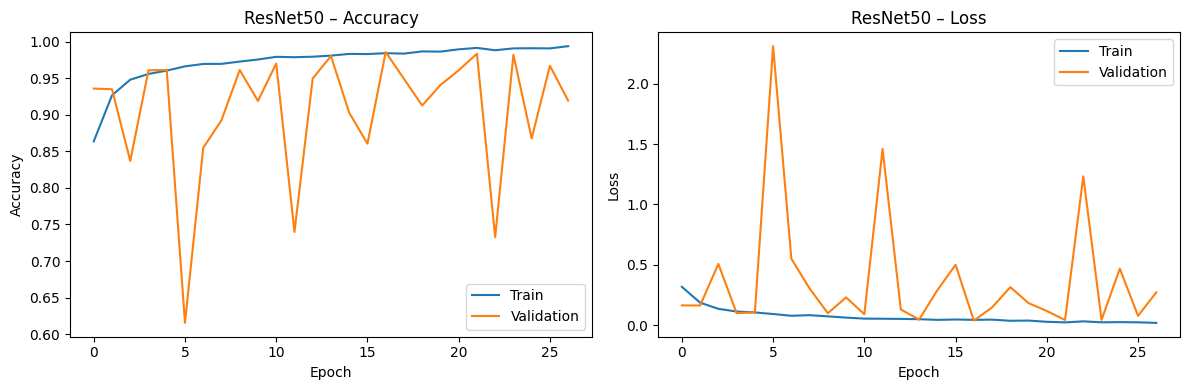


=== ResNet50 ===
Accuracy:  0.5662
Recall:    0.9657
Precision: 0.5368
F1-score:  0.6900
AUC-ROC:   0.7283
EER:       0.3456
Bootstrap: 0.5657 [0.5306, 0.5993]


In [20]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

X_train_resnet = resnet_preprocess(X_train_vgg)
X_val_resnet = resnet_preprocess(X_val_vgg)
X_test_resnet = resnet_preprocess(X_test_vgg)

base = ResNet50(include_top=False, weights="imagenet", input_shape=(224, 224, 3))
for layer in base.layers:
    layer.trainable = False
for layer in base.layers[-10:]:
    layer.trainable = True

inputs  = layers.Input(shape=(224, 224, 3))
x       = base(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(128, activation="relu")(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

resnet = models.Model(inputs, outputs)
resnet.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
resnet.summary()

history_resnet = resnet.fit(
    X_train_resnet, y_train,
    validation_data=(X_val_resnet, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("resnet_stft")
)

plot_history(history_resnet, "ResNet50")
results_resnet = evaluate_model(resnet, X_test_resnet, y_test, "ResNet50")

#MEL

###Imports and parametre

In [2]:
import os, math, shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import librosa
import librosa.display
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, classification_report,
    f1_score, roc_auc_score, roc_curve,
    recall_score, precision_score
)
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint

SR              = 16000
DURATION        = 2.0
TARGET_LEN      = int(SR * DURATION)
HOP_LENGTH      = 256
N_MELS          = 128
BATCH_SIZE      = 16
EPOCHS          = 50
INITIAL_LR      = 5e-5
PATIENCE        = 10

base_path  = "/content/for-rerec"
train_path = os.path.join(base_path, "training")
val_path   = os.path.join(base_path, "validation")
test_path  = os.path.join(base_path, "testing")

MEL Function & Load Data

In [3]:
def create_mel(filepath):
    audio, _ = librosa.load(filepath, sr=SR, mono=True)
    if len(audio) < TARGET_LEN:
        audio = np.pad(audio, (0, TARGET_LEN - len(audio)))
    else:
        audio = audio[:TARGET_LEN]
    mel = librosa.feature.melspectrogram(
        y=audio, sr=SR,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db.astype(np.float32)

def get_paths(split_path):
    real = sorted([
        os.path.join(split_path, "real", f)
        for f in os.listdir(os.path.join(split_path, "real"))
        if f.endswith(".wav")
    ])
    fake = sorted([
        os.path.join(split_path, "fake", f)
        for f in os.listdir(os.path.join(split_path, "fake"))
        if f.endswith(".wav")
    ])
    return real, fake

def load_split(split_path):
    real, fake = get_paths(split_path)
    X, y = [], []
    for fp in real:
        X.append(create_mel(fp))
        y.append(1)
    for fp in fake:
        X.append(create_mel(fp))
        y.append(0)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

print("Loading MEL data...")
X_train, y_train = load_split(train_path)
X_val, y_val = load_split(val_path)
X_test, y_test = load_split(test_path)

print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)
print(f"Data range: {X_train.min():.2f} to {X_train.max():.2f}")

Loading MEL data...
Train: (10208, 128, 126)
Val:   (2244, 128, 126)
Test:  (816, 128, 126)
Data range: -80.00 to 0.00


RGB Conversion

In [4]:
def to_rgb_resized(X, size):
    """Convert grayscale spectrograms to RGB and resize."""
    results = []
    for spec in X:
        spec_rgb = np.stack([spec, spec, spec], axis=-1)
        spec_resized = tf.image.resize(spec_rgb, (size, size)).numpy()
        results.append(spec_resized)
    return np.array(results, dtype=np.float32)

print("Converting to RGB...")
X_train_rgb96 = to_rgb_resized(X_train, 96)
X_val_rgb96   = to_rgb_resized(X_val, 96)
X_test_rgb96  = to_rgb_resized(X_test, 96)

X_train_vgg = to_rgb_resized(X_train, 224)
X_val_vgg   = to_rgb_resized(X_val, 224)
X_test_vgg  = to_rgb_resized(X_test, 224)

print("RGB 96 (MobileNet):", X_train_rgb96.shape)
print("VGG 224 (VGG16/VGG19/ResNet50):", X_train_vgg.shape)
print(f"RGB96 data range: {X_train_rgb96.min():.2f} to {X_train_rgb96.max():.2f}")

Converting to RGB...
RGB 96 (MobileNet): (10208, 96, 96, 3)
VGG 224 (VGG16/VGG19/ResNet50): (10208, 224, 224, 3)
RGB96 data range: -80.00 to -0.08


Z-Score Normalization

In [5]:
print("Z-score normalizing for custom CNNs...")

mean = X_train.mean(axis=(0, 1, 2), keepdims=True)
std  = X_train.std(axis=(0, 1, 2), keepdims=True) + 1e-8

X_train_norm = (X_train - mean) / std
X_val_norm   = (X_val   - mean) / std
X_test_norm  = (X_test  - mean) / std

X_train_norm = X_train_norm[..., np.newaxis]
X_val_norm   = X_val_norm[..., np.newaxis]
X_test_norm  = X_test_norm[..., np.newaxis]

print("Normalized train shape:", X_train_norm.shape)
print("Normalized val shape:  ", X_val_norm.shape)
print("Normalized test shape: ", X_test_norm.shape)

print(f"\nZ-scored data - Mean: {X_train_norm.mean():.6f}, Std: {X_train_norm.std():.6f}")
print(f"Z-scored range: {X_train_norm.min():.2f} to {X_train_norm.max():.2f}")

Z-score normalizing for custom CNNs...
Normalized train shape: (10208, 128, 126, 1)
Normalized val shape:   (2244, 128, 126, 1)
Normalized test shape:  (816, 128, 126, 1)

Z-scored data - Mean: -0.000002, Std: 1.000003
Z-scored range: -1.55 to 3.14


Helper Functions

In [6]:
class CosineAnnealingScheduler(Callback):
    def __init__(self, T_max, eta_max, eta_min=1e-6, verbose=0):
        super().__init__()
        self.T_max   = T_max
        self.eta_max = eta_max
        self.eta_min = eta_min
        self.verbose = verbose

    def on_epoch_begin(self, epoch, logs=None):
        lr = self.eta_min + (self.eta_max - self.eta_min) * (
            1 + math.cos(math.pi * epoch / self.T_max)
        ) / 2
        self.model.optimizer.learning_rate.assign(lr)
        if self.verbose:
            print(f"  LR: {lr:.2e}")

def get_callbacks(model_name):
    return [
        EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True, verbose=1),
        CosineAnnealingScheduler(T_max=EPOCHS, eta_max=INITIAL_LR, eta_min=1e-6),
        ModelCheckpoint(f"/content/{model_name}.keras", monitor="val_loss", save_best_only=True, verbose=1)
    ]

def equal_error_rate(y_true, y_scores):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    fnr = 1 - tpr
    idx = np.argmin(np.abs(fpr - fnr))
    return float(fpr[idx])

def bootstrap_ci(y_true, y_scores, n=1000, alpha=0.05):
    accs = []
    n_samples = len(y_true)
    for _ in range(n):
        idx = np.random.randint(0, n_samples, size=n_samples)
        y_b = y_true[idx]
        y_s = y_scores[idx]
        y_p = (y_s >= 0.5).astype(int)
        accs.append(accuracy_score(y_b, y_p))
    lower = np.percentile(accs, 100 * alpha / 2)
    upper = np.percentile(accs, 100 * (1 - alpha / 2))
    return np.mean(accs), lower, upper

def evaluate_model(model, X, y, model_name):
    y_prob  = model.predict(X, verbose=0).ravel()
    y_pred  = (y_prob >= 0.5).astype(int)
    acc     = accuracy_score(y, y_pred)
    recall  = recall_score(y, y_pred)
    prec    = precision_score(y, y_pred, zero_division=0)
    f1      = f1_score(y, y_pred)
    auc     = roc_auc_score(y, y_prob)
    eer     = equal_error_rate(y, y_prob)
    mean_acc, ci_low, ci_high = bootstrap_ci(y, y_prob)

    print(f"\n=== {model_name} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"AUC-ROC:   {auc:.4f}")
    print(f"EER:       {eer:.4f}")
    print(f"Bootstrap: {mean_acc:.4f} [{ci_low:.4f}, {ci_high:.4f}]")

    return {
        "model": model_name, "accuracy": acc, "recall": recall,
        "precision": prec, "f1": f1, "auc": auc, "eer": eer,
        "ci_low": ci_low, "ci_high": ci_high
    }

def plot_history(history, model_name):
    best_val_acc = max(history.history["val_accuracy"])
    print(f"Best val accuracy ({model_name}): {best_val_acc:.4f}")
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train")
    plt.plot(history.history["val_accuracy"], label="Validation")
    plt.title(f"{model_name} – Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train")
    plt.plot(history.history["val_loss"], label="Validation")
    plt.title(f"{model_name} – Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
    plt.tight_layout(); plt.show()

SpecAugment & Residual Block

In [7]:
class SpecAugment(layers.Layer):
    def __init__(self, freq_mask=10, time_mask=15, **kwargs):
        super().__init__(**kwargs)
        self.freq_mask = freq_mask
        self.time_mask = time_mask

    def call(self, x, training=None):
        if not training:
            return x
        freq = tf.shape(x)[1]
        time = tf.shape(x)[2]

        f  = tf.random.uniform([], 0, self.freq_mask, dtype=tf.int32)
        f0 = tf.random.uniform([], 0, freq - f, dtype=tf.int32)
        freq_mask = 1.0 - tf.cast(
            tf.sequence_mask(f, freq) & ~tf.sequence_mask(f0, freq),
            dtype=x.dtype
        )
        freq_mask = tf.reshape(freq_mask, [1, freq, 1, 1])
        x = x * freq_mask

        t  = tf.random.uniform([], 0, self.time_mask, dtype=tf.int32)
        t0 = tf.random.uniform([], 0, time - t, dtype=tf.int32)
        time_mask = 1.0 - tf.cast(
            tf.sequence_mask(t, time) & ~tf.sequence_mask(t0, time),
            dtype=x.dtype
        )
        time_mask = tf.reshape(time_mask, [1, 1, time, 1])
        x = x * time_mask
        return x

def residual_block(x, filters):
    shortcut = x
    x = layers.SeparableConv2D(filters, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.SeparableConv2D(filters, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1,1), padding="same", use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)
    return x

###Model 1: Simple CNN

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 126, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 63, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 31, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 15360)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       983,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,006,465 (3.84 MB)

 Trainable params: 1,006,465 (3.84 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
638/638 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6314 - loss: 0.6204
Epoch 1: val_loss improved from None to 0.37372, saving model to /content/simple_cnn_mel.keras

Epoch 1: finished saving model to /content/simple_cnn_mel.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.7271 - loss: 0.5332 - val_accuracy: 0.8659 - val_loss: 0.3737
Epoch 2/50
634/638 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8504 - loss: 0.3731
Epoch 2: val_loss improved from 0.37372 to 0.32515, saving model to /content/simple_cnn_mel.keras

Epoch 2: finished saving model to /content/simple_cnn_mel.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8630 - loss: 0.3442 - val_accuracy: 0.8668 - val_loss: 0.3252
Epoch 3/50
635/638 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8847 - loss: 0.2925
Epoch 3: val_loss improved from 0.32515 to 0.24994, saving model to /content/simple_cnn_mel.keras

Epoch 3: finished saving model to /content/simple_cnn_mel.keras
638/638 ━━━━━━━━━━━━━

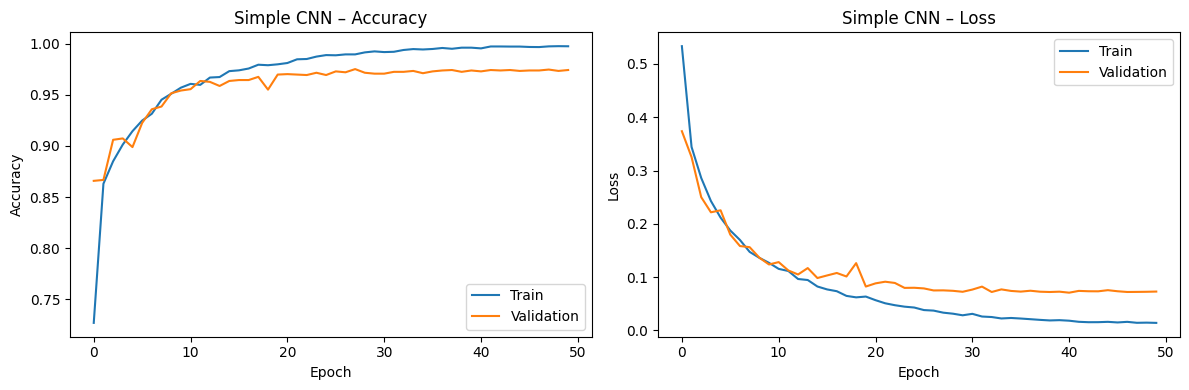


=== Simple CNN ===
Accuracy:  0.8235
Recall:    0.9387
Precision: 0.7629
F1-score:  0.8418
AUC-ROC:   0.9259
EER:       0.1397
Bootstrap: 0.8238 [0.8002, 0.8493]


In [8]:
input_shape = X_train_norm.shape[1:]
simple_cnn = models.Sequential([
    layers.Input(shape=input_shape),
    layers.Conv2D(16, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

simple_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
simple_cnn.summary()

history_simple = simple_cnn.fit(
    X_train_norm, y_train,
    validation_data=(X_val_norm, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks("simple_cnn_mel")
)
plot_history(history_simple, "Simple CNN")
results_simple = evaluate_model(simple_cnn, X_test_norm, y_test, "Simple CNN")

###Model 2 Improved CNN

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 126,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 126,  │        288 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 126,  │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 126,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 64, 63,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 64, 63,    │      2,336 │ max_pooling2d_3[… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 63,    │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 64, 63,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 64, 63,    │      4,672 │ activation_1[0][… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 63,    │      2,048 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 63,    │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 63,    │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 63,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 63,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 32, 31,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 32, 31,    │      8,768 │ max_pooling2d_4[… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 31,    │        512 │ separable_conv2d

 Total params: 184,129 (719.25 KB)

 Trainable params: 181,377 (708.50 KB)

 Non-trainable params: 2,752 (10.75 KB)

Epoch 1/50
636/638 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6752 - loss: 0.5966
Epoch 1: val_loss improved from None to 1.17489, saving model to /content/improved_cnn_mel.keras

Epoch 1: finished saving model to /content/improved_cnn_mel.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 40s 33ms/step - accuracy: 0.7643 - loss: 0.4747 - val_accuracy: 0.4996 - val_loss: 1.1749
Epoch 2/50
637/638 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8851 - loss: 0.2765
Epoch 2: val_loss improved from 1.17489 to 0.15192, saving model to /content/improved_cnn_mel.keras

Epoch 2: finished saving model to /content/improved_cnn_mel.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.8996 - loss: 0.2425 - val_accuracy: 0.9483 - val_loss: 0.1519
Epoch 3/50
637/638 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9354 - loss: 0.1796
Epoch 3: val_loss did not improve from 0.15192
638/638 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9362 - loss: 0.1714 - val_accuracy: 0.9171 - val_loss: 0.2115
Epoc

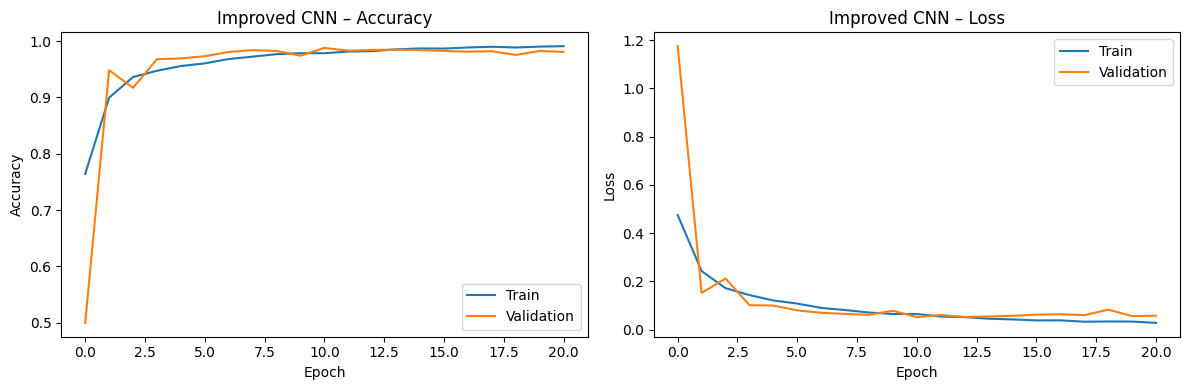


=== Improved CNN ===
Accuracy:  0.6164
Recall:    0.9583
Precision: 0.5691
F1-score:  0.7142
AUC-ROC:   0.8040
EER:       0.2819
Bootstrap: 0.6166 [0.5846, 0.6495]


In [9]:
input_shape = X_train_norm.shape[1:]
inputs = layers.Input(shape=input_shape)
x = layers.Conv2D(32, (3,3), padding="same", use_bias=False)(inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.MaxPooling2D((2,2))(x)
x = residual_block(x, 64)
x = layers.MaxPooling2D((2,2))(x)
x = residual_block(x, 128)
x = layers.MaxPooling2D((2,2))(x)
x = residual_block(x, 256)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

improved_cnn = models.Model(inputs, outputs)
improved_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
improved_cnn.summary()

history_improved = improved_cnn.fit(
    X_train_norm, y_train,
    validation_data=(X_val_norm, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks("improved_cnn_mel")
)
plot_history(history_improved, "Improved CNN")
results_improved = evaluate_model(improved_cnn, X_test_norm, y_test, "Improved CNN")

###Model 3:Improved CNN + SpecAugment

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 126,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spec_augment        │ (None, 128, 126,  │          0 │ input_layer_2[0]… │
│ (SpecAugment)       │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 128, 126,  │        288 │ spec_augment[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 126,  │        128 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 128, 126,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 64, 63,    │          0 │ activation_7[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_6  │ (None, 64, 63,    │      2,336 │ max_pooling2d_6[… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 63,    │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 64, 63,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_7  │ (None, 64, 63,    │      4,672 │ activation_8[0][… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 64, 63,    │      2,048 │ max_pooling2d_6[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 63,    │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 63,    │        256 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 64, 63,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 64, 63,    │          0 │ add_3[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 32, 31,    │          0 │ activation_9[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_8  │ (None, 32, 31,    │      8,768 │ max_pooling2d_7[

 Total params: 184,129 (719.25 KB)

 Trainable params: 181,377 (708.50 KB)

 Non-trainable params: 2,752 (10.75 KB)

Epoch 1/50
637/638 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6806 - loss: 0.5797
Epoch 1: val_loss improved from None to 0.92456, saving model to /content/improved_cnn_aug_mel.keras

Epoch 1: finished saving model to /content/improved_cnn_aug_mel.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 32s 27ms/step - accuracy: 0.7538 - loss: 0.4950 - val_accuracy: 0.5156 - val_loss: 0.9246
Epoch 2/50
637/638 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8631 - loss: 0.3151
Epoch 2: val_loss improved from 0.92456 to 0.17603, saving model to /content/improved_cnn_aug_mel.keras

Epoch 2: finished saving model to /content/improved_cnn_aug_mel.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.8803 - loss: 0.2835 - val_accuracy: 0.9385 - val_loss: 0.1760
Epoch 3/50
637/638 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9210 - loss: 0.2066
Epoch 3: val_loss did not improve from 0.17603
638/638 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.9265 - loss: 0.1940 - val_accuracy: 0.9046 - val_l

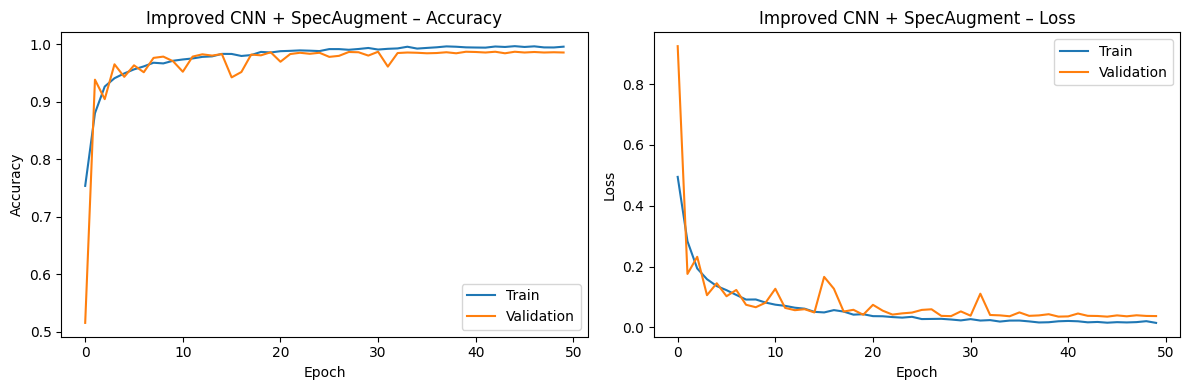


=== Improved CNN + SpecAugment ===
Accuracy:  0.7120
Recall:    0.9363
Precision: 0.6464
F1-score:  0.7648
AUC-ROC:   0.8304
EER:       0.2696
Bootstrap: 0.7121 [0.6814, 0.7439]


In [10]:
input_shape = X_train_norm.shape[1:]
inputs = layers.Input(shape=input_shape)
x = SpecAugment()(inputs)
x = layers.Conv2D(32, (3,3), padding="same", use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.MaxPooling2D((2,2))(x)
x = residual_block(x, 64)
x = layers.MaxPooling2D((2,2))(x)
x = residual_block(x, 128)
x = layers.MaxPooling2D((2,2))(x)
x = residual_block(x, 256)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

improved_cnn_aug = models.Model(inputs, outputs)
improved_cnn_aug.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
improved_cnn_aug.summary()

history_improved_aug = improved_cnn_aug.fit(
    X_train_norm, y_train,
    validation_data=(X_val_norm, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks("improved_cnn_aug_mel")
)
plot_history(history_improved_aug, "Improved CNN + SpecAugment")
results_improved_aug = evaluate_model(improved_cnn_aug, X_test_norm, y_test, "Improved CNN + SpecAugment")

###Model 4: Mini-Xception

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 128, 126,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 128, 126,  │        288 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 126,  │        128 │ conv2d_11[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_14       │ (None, 128, 126,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_12 │ (None, 128, 126,  │      1,312 │ activation_14[0]… │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 126,  │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_15       │ (None, 128, 126,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_13 │ (None, 128, 126,  │      1,312 │ activation_15[0]… │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 126,  │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 64, 63,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 64, 63,    │          0 │ activation_14[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 64, 63,    │          0 │ max_pooling2d_9[… │
│                     │ 32)               │            │ max_pooling2d_10… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_14 │ (None, 64, 63,    │      2,336 │ add_6[0][0]       │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 63,    │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_16       │ (None, 64, 63,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_15 │ (None, 64, 63,    │      4,672 │ activation_16[0]… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 64, 63,    │      2,048 │ add_6[0][0]     

 Total params: 187,009 (730.50 KB)

 Trainable params: 184,129 (719.25 KB)

 Non-trainable params: 2,880 (11.25 KB)

Epoch 1/50
637/638 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6156 - loss: 0.7816
Epoch 1: val_loss improved from None to 0.50707, saving model to /content/mini_xception_mel.keras

Epoch 1: finished saving model to /content/mini_xception_mel.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 52s 49ms/step - accuracy: 0.6942 - loss: 0.6454 - val_accuracy: 0.7500 - val_loss: 0.5071
Epoch 2/50
637/638 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8315 - loss: 0.3810
Epoch 2: val_loss improved from 0.50707 to 0.27379, saving model to /content/mini_xception_mel.keras

Epoch 2: finished saving model to /content/mini_xception_mel.keras
638/638 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - accuracy: 0.8539 - loss: 0.3383 - val_accuracy: 0.8846 - val_loss: 0.2738
Epoch 3/50
637/638 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8971 - loss: 0.2412
Epoch 3: val_loss did not improve from 0.27379
638/638 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.9050 - loss: 0.2266 - val_accuracy: 0.8766 - val_loss: 0.2900


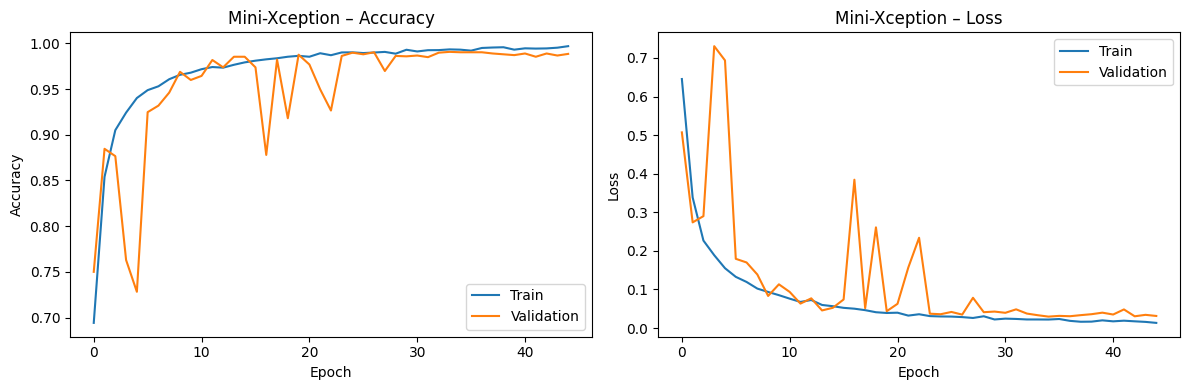


=== Mini-Xception ===
Accuracy:  0.6581
Recall:    0.9608
Precision: 0.5985
F1-score:  0.7375
AUC-ROC:   0.8059
EER:       0.2745
Bootstrap: 0.6584 [0.6250, 0.6912]


In [11]:
input_shape = X_train_norm.shape[1:]

inputs = layers.Input(shape=input_shape)
x = layers.Conv2D(32, (3,3), padding="same", use_bias=False)(inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

for filters in [32, 64, 128, 256]:
    residual = x
    x = layers.SeparableConv2D(filters, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.SeparableConv2D(filters, (3,3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2), padding="same")(x)
    if residual.shape[-1] != filters:
        residual = layers.Conv2D(filters, (1,1), padding="same", use_bias=False)(residual)
        residual = layers.BatchNormalization()(residual)
    residual = layers.MaxPooling2D((2,2), padding="same")(residual)
    x = layers.Add()([x, residual])

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

mini_xception = models.Model(inputs, outputs)
mini_xception.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
mini_xception.summary()

history_xception = mini_xception.fit(
    X_train_norm, y_train,
    validation_data=(X_val_norm, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks("mini_xception_mel")
)
plot_history(history_xception, "Mini-Xception")
results_xception = evaluate_model(mini_xception, X_test_norm, y_test, "Mini-Xception")

###Model 5: MobileNet

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

X_train_mob = mobilenet_preprocess(X_train_rgb96)
X_val_mob = mobilenet_preprocess(X_val_rgb96)
X_test_mob = mobilenet_preprocess(X_test_rgb96)

base = MobileNetV2(input_shape=(96, 96, 3), include_top=False, weights="imagenet")
base.trainable = True
for layer in base.layers[:-5]:
    layer.trainable = False

inputs  = layers.Input(shape=(96, 96, 3))
x       = base(inputs, training=False)
x       = layers.BatchNormalization()(x)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(128, activation="relu")(x)
x       = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

mobilenet = models.Model(inputs, outputs)
mobilenet.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
mobilenet.summary()

history_mobilenet = mobilenet.fit(
    X_train_mob, y_train,
    validation_data=(X_val_mob, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("mobilenet_mel"),
    verbose=1
)

plot_history(history_mobilenet, "MobileNet")
results_mobilenet = evaluate_model(mobilenet, X_test_mob, y_test, "MobileNet")

###Model 6: VGG16

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess

X_train_vgg16 = vgg16_preprocess(X_train_vgg)
X_val_vgg16 = vgg16_preprocess(X_val_vgg)
X_test_vgg16 = vgg16_preprocess(X_test_vgg)

def build_vgg(vgg_class):
    base = vgg_class(include_top=False, weights="imagenet", input_shape=(224, 224, 3))
    for layer in base.layers:
        layer.trainable = False
    for layer in base.layers[-5:]:
        layer.trainable = True

    inputs  = layers.Input(shape=(224, 224, 3))
    x       = base(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dropout(0.4)(x)
    x       = layers.Dense(128, activation="relu")(x)
    x       = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    model.summary()
    return model

vgg16 = build_vgg(VGG16)

history_vgg16 = vgg16.fit(
    X_train_vgg16, y_train,
    validation_data=(X_val_vgg16, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks("vgg16_mel")
)
plot_history(history_vgg16, "VGG16")
results_vgg16 = evaluate_model(vgg16, X_test_vgg16, y_test, "VGG16")

###Model 7: VGG19

In [ ]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input as vgg19_preprocess

X_train_vgg19 = vgg19_preprocess(X_train_vgg)
X_val_vgg19 = vgg19_preprocess(X_val_vgg)
X_test_vgg19 = vgg19_preprocess(X_test_vgg)

base = VGG19(include_top=False, weights="imagenet", input_shape=(224, 224, 3))
for layer in base.layers:
    layer.trainable = False
for layer in base.layers[-10:]:
    layer.trainable = True

inputs  = layers.Input(shape=(224, 224, 3))
x       = base(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(128, activation="relu")(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

vgg19 = models.Model(inputs, outputs)
vgg19.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
vgg19.summary()

history_vgg19 = vgg19.fit(
    X_train_vgg19, y_train,
    validation_data=(X_val_vgg19, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks("vgg19_mel")
)
plot_history(history_vgg19, "VGG19")
results_vgg19 = evaluate_model(vgg19, X_test_vgg19, y_test, "VGG19")

###Model 8: Improved VGG19

In [ ]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input

def to_vgg_optimized_from_rgb(X_rgb):
    """Preprocess from already-resized RGB data (224x224x3)."""
    X_out = []
    for img in X_rgb:
        img_single = img[:, :, 0]
        img_single = np.flipud(img_single)
        img_stacked = np.stack([img_single, img_single, img_single], axis=-1)
        img_preprocessed = preprocess_input(img_stacked)
        X_out.append(img_preprocessed)
    return np.array(X_out, dtype=np.float32)

X_train_opt = to_vgg_optimized_from_rgb(X_train_vgg)
X_val_opt   = to_vgg_optimized_from_rgb(X_val_vgg)
X_test_opt  = to_vgg_optimized_from_rgb(X_test_vgg)

base_model = VGG19(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers:
    layer.trainable = False
for layer in base_model.layers[-5:]:
    layer.trainable = True

inputs  = layers.Input(shape=(224, 224, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(128, activation="relu")(x)
x       = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

vgg19_opt = models.Model(inputs, outputs)
vgg19_opt.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
vgg19_opt.summary()

history_vgg19_opt = vgg19_opt.fit(
    X_train_opt, y_train,
    validation_data=(X_val_opt, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("vgg19_opt_mel")
)

plot_history(history_vgg19_opt, "VGG19 Optimized")
results_vgg19_opt = evaluate_model(vgg19_opt, X_test_opt, y_test, "VGG19 Optimized")

###Model 9: ResNet50

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

X_train_resnet = resnet_preprocess(X_train_vgg)
X_val_resnet = resnet_preprocess(X_val_vgg)
X_test_resnet = resnet_preprocess(X_test_vgg)

base = ResNet50(include_top=False, weights="imagenet", input_shape=(224, 224, 3))
for layer in base.layers:
    layer.trainable = False
for layer in base.layers[-10:]:
    layer.trainable = True

inputs  = layers.Input(shape=(224, 224, 3))
x       = base(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(128, activation="relu")(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

resnet = models.Model(inputs, outputs)
resnet.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
resnet.summary()

history_resnet = resnet.fit(
    X_train_resnet, y_train,
    validation_data=(X_val_resnet, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("resnet_mel")
)

plot_history(history_resnet, "ResNet50")
results_resnet = evaluate_model(resnet, X_test_resnet, y_test, "ResNet50")

#MFCC

<<3